In [2]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random
import bacco

import bacco
from bacco.halo import virial_mass_converter, virial_concentration_converter


%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
bacco.configuration.config['growth']['method']='reps'

In [4]:
import emcee
import corner

In [5]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [6]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

### Get Parameters

In [7]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))
        
rho_rec_or = np.log10(rho_rec_or)
ef_kin_or  = np.log10(ef_kin_or)

wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [8]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

In [9]:
def pars(i, mstar):

    arr = np.vstack( ( mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * rho_rec[i],\
                        np.ones(len(mstar)) * sf_ts[i],\
                        np.ones(len(mstar)) * ef_kin[i],\
                        np.ones(len(mstar)) * ef_high[i],\
                        np.ones(len(mstar)) * f_re[i])).T

    return arr

## Load the SMF

In [10]:
Nbins_smf = 15
Nbins_fgas = 8

zoom_smf = {}
zoom_fgas = {}
for i in range(len(name_list)):
    zoom_smf[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_{}_Nbins{:d}.npy".format(name_list[i], Nbins_smf), allow_pickle=True)[0]
    zoom_fgas[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/fgas/fgas_{}_Nbins{:d}.npy".format(name_list[i], Nbins_fgas), allow_pickle=True)[0]

In [11]:
# Filter NaNs
for i in range(len(name_list)):
    mask = ~np.isnan(zoom_smf[name_list[i]]['smf'][0]) & ~np.isnan(zoom_smf[name_list[i]]['mstar'][0])
    
    zoom_smf[name_list[i]]['smf'][0] = zoom_smf[name_list[i]]['smf'][0][mask]
    zoom_smf[name_list[i]]['mstar'][0] = zoom_smf[name_list[i]]['mstar'][0][mask]

    mask = ~np.isnan(zoom_fgas[name_list[i]]['m500c'][0])

    zoom_fgas[name_list[i]]['f_gas'][0] = zoom_fgas[name_list[i]]['f_gas'][0][mask]
    zoom_fgas[name_list[i]]['m500c'][0] = zoom_fgas[name_list[i]]['m500c'][0][mask]

In [12]:
train_sel = np.arange(31)

In [13]:
#del smf_global, arr_global
pars_global = pars(train_sel[0], np.log10(zoom_smf[name_list[train_sel[0]]]['mstar'][0]) )
smf_global = np.log10(zoom_smf[name_list[train_sel[0]]]['smf'][0])

for i in range(len(train_sel)):
    mstar = np.log10(zoom_smf[name_list[train_sel[i]]]['mstar'][0])

    arr = pars(train_sel[i], mstar)

    pars_global = np.vstack((pars_global, arr))

    smf_global = np.hstack((smf_global, np.log10(zoom_smf[name_list[train_sel[i]]]['smf'][0])))

In [14]:
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(smf_global, dtype=torch.float)

In [15]:
torch.set_num_threads(8)

### Build the SMF Model

In [16]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=8))

    def initialize(self):
        # reset constant mean to something reasonable
        self.mean_module.constant.data.normal_(0, 0.1)

        # lengthscales (ARD) :
        # initialize in log-space so we get spread over ~[0.3, 3] in standardized units
        with torch.no_grad():
            ls = 0.5 + torch.rand_like(self.covar_module.base_kernel.lengthscale)
            self.covar_module.base_kernel.lengthscale.copy_(ls)

        # reset outputscale
        self.covar_module.outputscale = 1.0

        # reset likelihood noise to moderate value
        self.likelihood.noise = 0.05

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood_smf = gpytorch.likelihoods.GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-2))
model_smf = ExactGPModel(train_x, train_y, likelihood_smf)

#### Train it

In [17]:
# this is for running the notebook in our testing framework
import os
import copy
smoke_test = ('CI' in os.environ)
#training_iter = 2 if smoke_test else 200

n_restarts = 30
steps_per_restart = 30

best_state = None
best_loss = float('inf')

for r in range(n_restarts):
    print(f"\n=== Restart {r+1}/{n_restarts} ===")
    model_smf.initialize()

    # Find optimal model hyperparameters
    model_smf.train()
    likelihood_smf.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(model_smf.parameters(), lr=0.01)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_smf, model_smf)

    for i in range(steps_per_restart):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model_smf(train_x)
        # Calc loss and backprop gradients
        loss = -torch.sum(mll(output, train_y))
        loss.backward()
        optimizer.step()

    # compute final loss for this restart
    with torch.no_grad():
        final_output = model_smf(train_x)
        final_loss = float(-mll(final_output, train_y))

    print(f"Final loss restart {r+1}: {final_loss:.4f}")

    # store best
    if final_loss < best_loss:
        best_loss = final_loss
        best_state = {
            'model': copy.deepcopy(model_smf.state_dict()),
            'likelihood': copy.deepcopy(likelihood_smf.state_dict()),
        }


=== Restart 1/30 ===
Final loss restart 1: 1.3570

=== Restart 2/30 ===
Final loss restart 2: 1.1512

=== Restart 3/30 ===
Final loss restart 3: 0.9565

=== Restart 4/30 ===
Final loss restart 4: 0.7753

=== Restart 5/30 ===
Final loss restart 5: 0.6958

=== Restart 6/30 ===
Final loss restart 6: 0.5972

=== Restart 7/30 ===
Final loss restart 7: 0.5245

=== Restart 8/30 ===
Final loss restart 8: 0.4717

=== Restart 9/30 ===
Final loss restart 9: 0.4151

=== Restart 10/30 ===
Final loss restart 10: 0.3923

=== Restart 11/30 ===
Final loss restart 11: 0.3703

=== Restart 12/30 ===
Final loss restart 12: 0.3269

=== Restart 13/30 ===
Final loss restart 13: 0.3129

=== Restart 14/30 ===
Final loss restart 14: 0.2964

=== Restart 15/30 ===
Final loss restart 15: 0.2650

=== Restart 16/30 ===
Final loss restart 16: 0.2554

=== Restart 17/30 ===
Final loss restart 17: 0.2406

=== Restart 18/30 ===
Final loss restart 18: 0.2288

=== Restart 19/30 ===
Final loss restart 19: 0.2206

=== Restar

In [18]:
# ---- restore best ----
model_smf.load_state_dict(best_state['model'])
likelihood_smf.load_state_dict(best_state['likelihood'])

<All keys matched successfully>

In [19]:
print(model_smf.covar_module.base_kernel.lengthscale)
print(model_smf.covar_module.outputscale)
print(torch.sqrt(model_smf.likelihood.noise_covar.noise))

tensor([[0.9775, 8.8357, 5.3877, 5.5864, 8.8307, 8.0706, 8.8277, 8.8465]],
       grad_fn=<SoftplusBackward0>)
tensor(1.1874, grad_fn=<SoftplusBackward0>)
tensor([0.2368], grad_fn=<SqrtBackward0>)


In [20]:
# Get into evaluation (predictive posterior) mode
model_smf.eval()
likelihood_smf.eval()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

In [21]:
# Stellar Mass Function from  GAMA (corrected to h=0.7)
# https://arxiv.org/pdf/2203.08539
# For SDSS correction, add 0.0807 dex to number density

GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = GAMA[:,0] - 2*np.log10(0.7)
GAMA_corr[:,1] = GAMA[:,1] + 3*np.log10(0.7)
GAMA_corr[:,2] = GAMA[:,2]

def model_GAMA(GAMA_corr, b_star, b_cv):

    GAMA_corr = np.copy(GAMA_corr)
    GAMA_corr[:,1] = GAMA_corr[:,1] + np.log10(b_cv)
    GAMA_corr[:,0] = GAMA_corr[:,0] + b_star

    return GAMA_corr

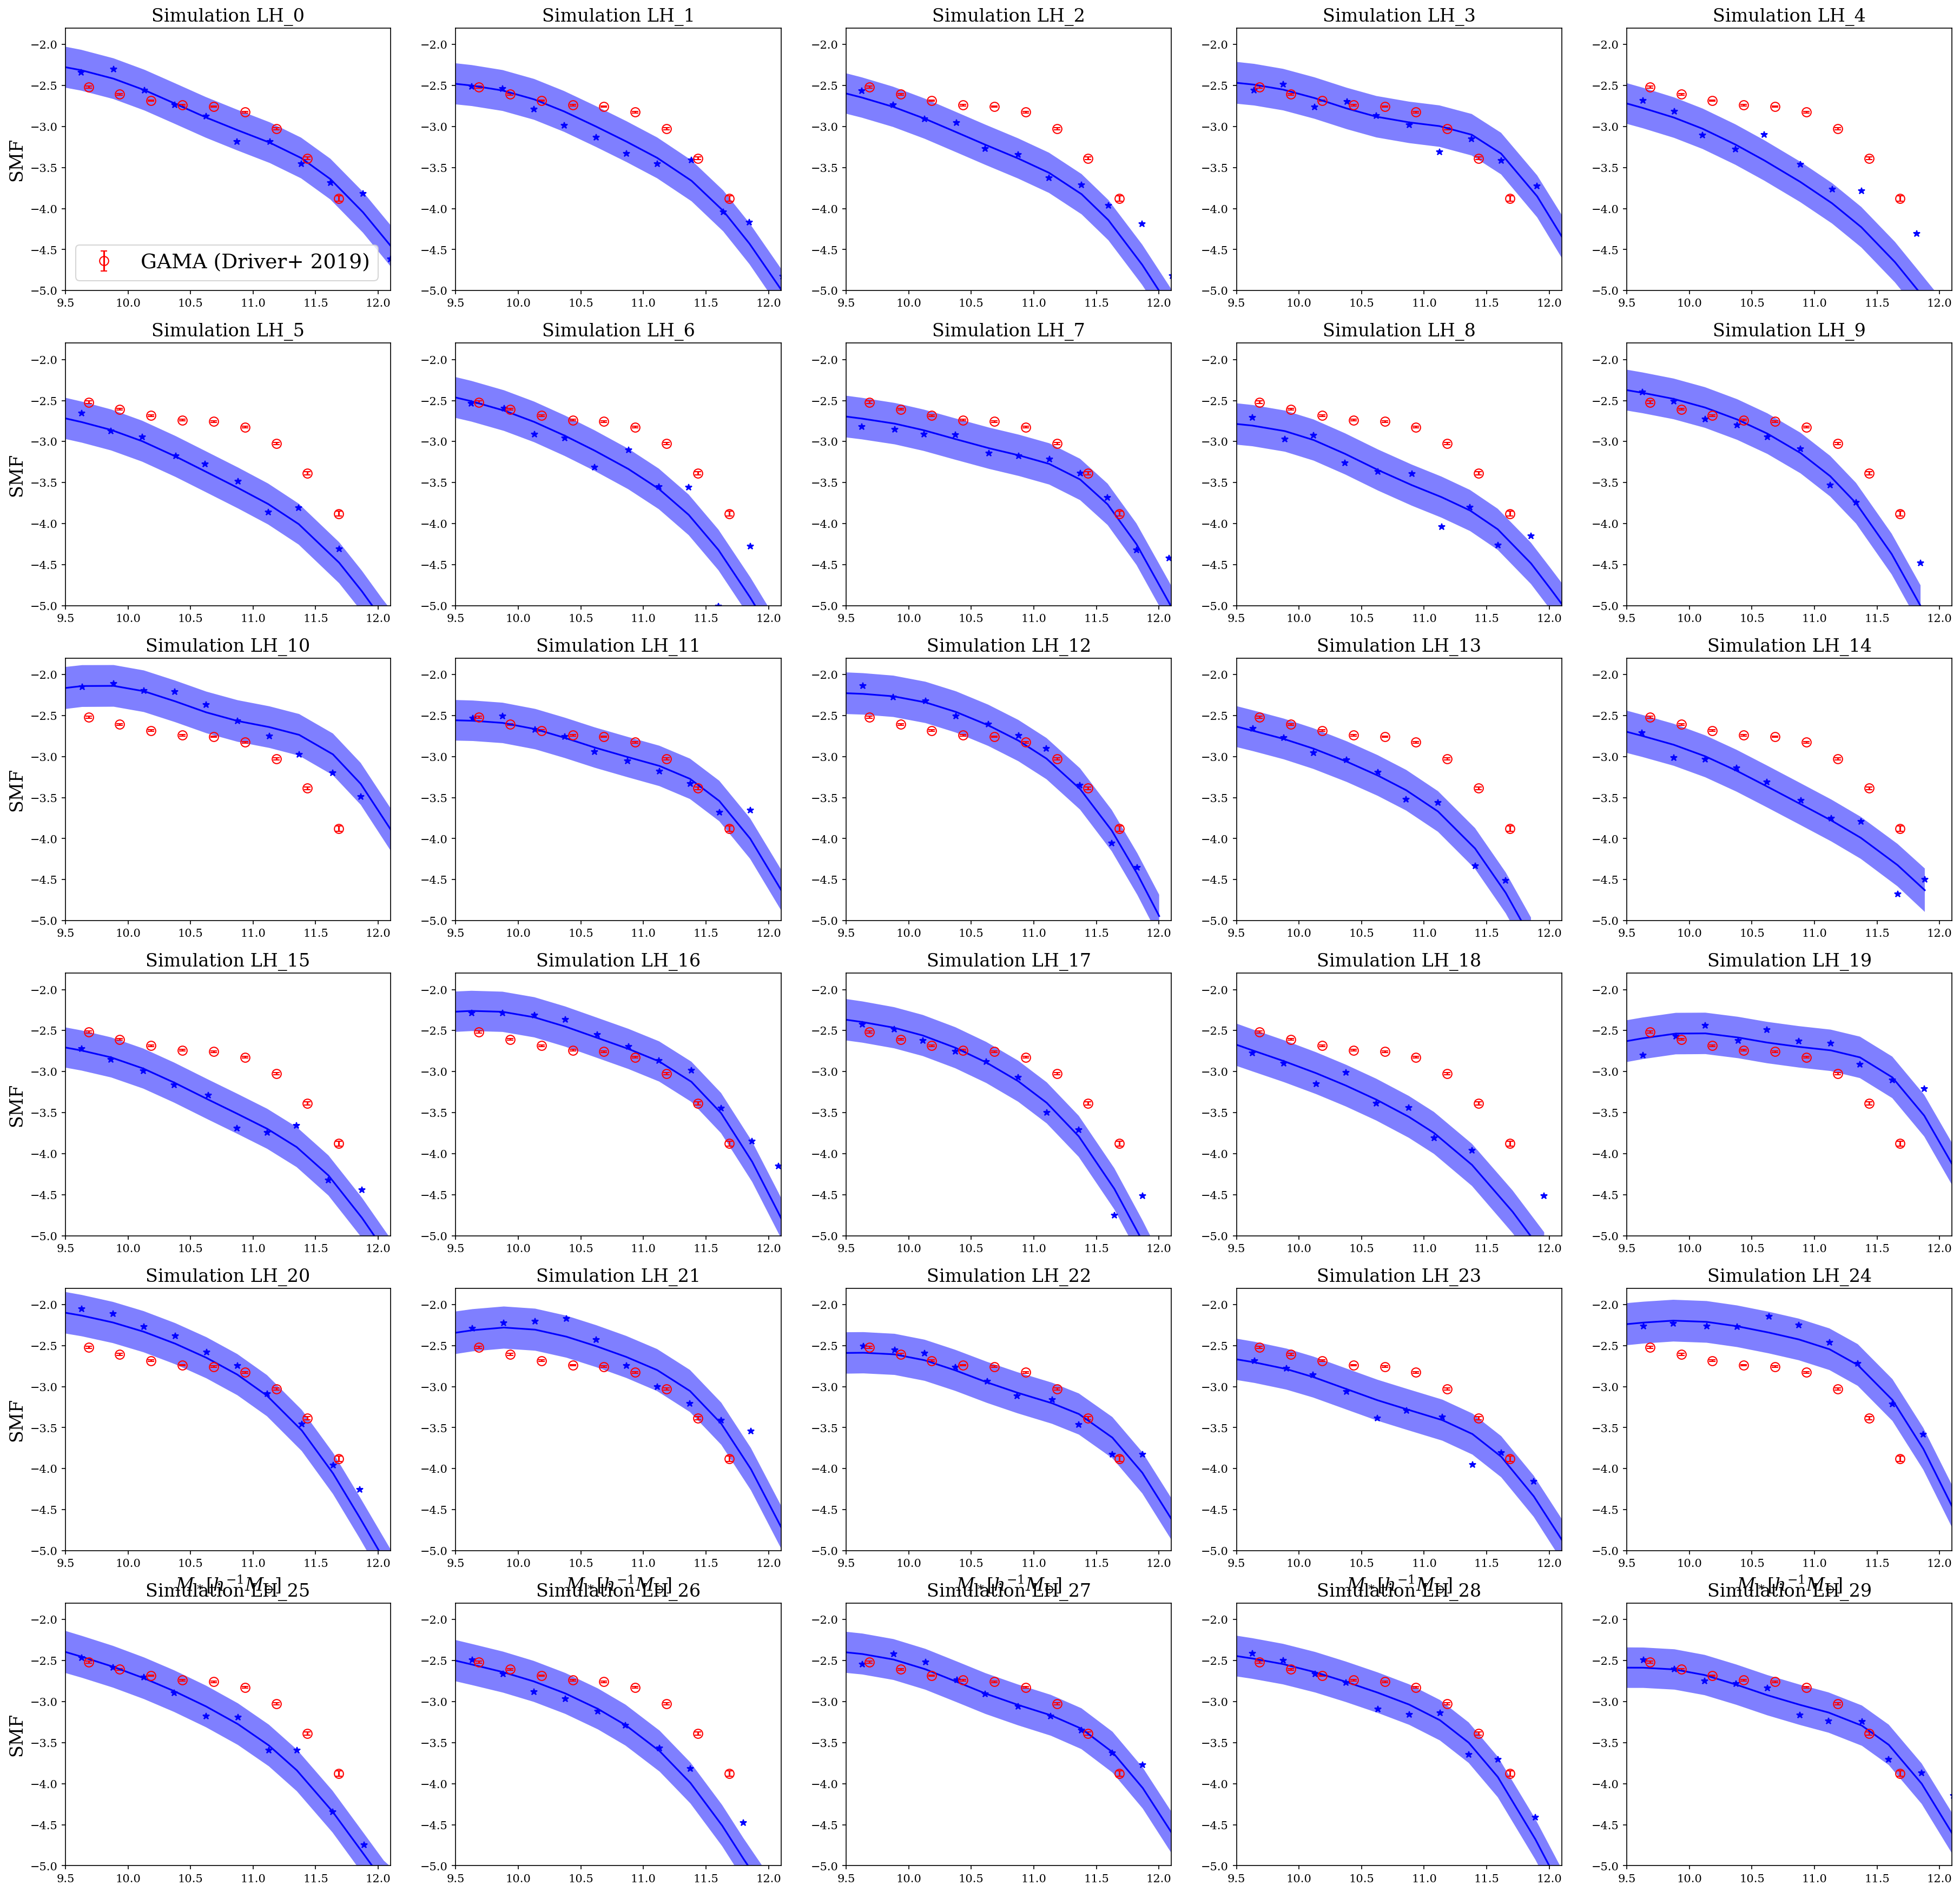

In [22]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(6, 5, figsize=(30, 30), dpi=150)

    for i in range(6):
        for j in range(5):
            test_x = torch.asarray(pars(train_sel[5*i+j], np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0])), dtype=torch.float)
            observed_pred = likelihood_smf(model_smf(torch.asarray(test_x, dtype=torch.float)))

            ax[i,j].set_title('Simulation {:s}'.format(name_list[train_sel[5*i+j]]), fontsize=16)
            ax[i,j].errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=GAMA_corr[:,2], color='r', marker='o', capsize=3, ms=8, fillstyle='none', ls='', label='GAMA (Driver+ 2019)')

            ax[i,j].set_xlim(9.5,12.1)
            ax[i,j].set_ylim(-5, -1.8)

            if j==0:
                ax[i,j].set_ylabel('SMF', fontsize=16)
            if i==4:
                ax[i,j].set_xlabel('$M_*[h^{-1}M_{\odot}]$', fontsize=16)

            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot training data as black stars
            ax[i,j].plot(np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['mstar'][0]), np.log10(zoom_smf[name_list[train_sel[5*i+j]]]['smf'][0]), 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

ax[0,0].legend(loc='lower left', fontsize=18)

# ax.set_xlabel('$M_*$')
# ax.set_ylabel('SMF')


In [67]:
save_path = "/cosmos_storage/home/fgmaion/MTNG-resims/gp_training/"

torch.save({'model_state_dict':model_smf.state_dict(),
            'likelihood_state_dict':likelihood_smf.state_dict()}, save_path + "model_smf.pth")

### Build training set

In [23]:
#del smf_global, arr_global
pars_global = pars(train_sel[0], np.log10(zoom_fgas[name_list[train_sel[0]]]['m500c'][0]))
fgas_global = zoom_fgas[name_list[train_sel[0]]]['f_gas'][0]

for i in range(len(train_sel)):
    m500c = np.log10(zoom_fgas[name_list[train_sel[i]]]['m500c'][0])

    arr = pars(train_sel[i], m500c)

    pars_global = np.vstack((pars_global, arr))

    fgas_global = np.hstack((fgas_global, zoom_fgas[name_list[train_sel[i]]]['f_gas'][0]))

In [24]:
train_x = torch.asarray(pars_global, dtype=torch.float)
train_y = torch.asarray(fgas_global, dtype=torch.float)

## Build the $f_{gas}$ model

In [25]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=8))

    def initialize(self):
        # reset constant mean to something reasonable
        self.mean_module.constant.data.normal_(0, 0.1)

        # lengthscales (ARD) :
        # initialize in log-space so we get spread over ~[0.3, 3] in standardized units
        with torch.no_grad():
            ls = 0.5 + torch.rand_like(self.covar_module.base_kernel.lengthscale)
            self.covar_module.base_kernel.lengthscale.copy_(ls)

        # reset outputscale
        self.covar_module.outputscale = 1.0

        # reset likelihood noise to moderate value
        self.likelihood.noise = 1e-4

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood_fgas = gpytorch.likelihoods.GaussianLikelihood(noise_constraint=gpytorch.constraints.GreaterThan(1e-6))
model_fgas = ExactGPModel(train_x, train_y, likelihood_fgas)

### Train it

In [26]:
# this is for running the notebook in our testing framework
import os
import copy
smoke_test = ('CI' in os.environ)
#training_iter = 2 if smoke_test else 200

n_restarts = 200
steps_per_restart = 20

best_state = None
best_loss = float('inf')

for r in range(n_restarts):
    print(f"\n=== Restart {r+1}/{n_restarts} ===")
    model_fgas.initialize()

    # Find optimal model hyperparameters
    model_fgas.train()
    likelihood_fgas.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(model_fgas.parameters(), lr=0.01)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_fgas, model_fgas)

    for i in range(steps_per_restart):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model_fgas(train_x)
        # Calc loss and backprop gradients
        loss = -torch.sum(mll(output, train_y))
        loss.backward()
        optimizer.step()

    # compute final loss for this restart
    with torch.no_grad():
        final_output = model_fgas(train_x)
        final_loss = float(-mll(final_output, train_y))

    print(f"Final loss restart {r+1}: {final_loss:.4f}")

    # store best
    if final_loss < best_loss:
        best_loss = final_loss
        best_state = {
            'model': copy.deepcopy(model_fgas.state_dict()),
            'likelihood': copy.deepcopy(likelihood_fgas.state_dict()),
        }


=== Restart 1/200 ===
Final loss restart 1: -0.6939

=== Restart 2/200 ===
Final loss restart 2: -0.8983

=== Restart 3/200 ===
Final loss restart 3: -1.0823

=== Restart 4/200 ===
Final loss restart 4: -1.2459

=== Restart 5/200 ===
Final loss restart 5: -1.3932

=== Restart 6/200 ===
Final loss restart 6: -1.5275

=== Restart 7/200 ===
Final loss restart 7: -1.6500

=== Restart 8/200 ===
Final loss restart 8: -1.7617

=== Restart 9/200 ===
Final loss restart 9: -1.8638

=== Restart 10/200 ===
Final loss restart 10: -1.9567

=== Restart 11/200 ===
Final loss restart 11: -2.0411

=== Restart 12/200 ===
Final loss restart 12: -2.1174

=== Restart 13/200 ===
Final loss restart 13: -2.1863

=== Restart 14/200 ===
Final loss restart 14: -2.2485

=== Restart 15/200 ===
Final loss restart 15: -2.3045

=== Restart 16/200 ===
Final loss restart 16: -2.3549

=== Restart 17/200 ===
Final loss restart 17: -2.3997

=== Restart 18/200 ===


Final loss restart 18: -2.4393

=== Restart 19/200 ===
Final loss restart 19: -2.4738

=== Restart 20/200 ===
Final loss restart 20: -2.5038

=== Restart 21/200 ===
Final loss restart 21: -2.5301

=== Restart 22/200 ===
Final loss restart 22: -2.5531

=== Restart 23/200 ===
Final loss restart 23: -2.5727

=== Restart 24/200 ===
Final loss restart 24: -2.5901

=== Restart 25/200 ===
Final loss restart 25: -2.6077

=== Restart 26/200 ===
Final loss restart 26: -2.6246

=== Restart 27/200 ===
Final loss restart 27: -2.6404

=== Restart 28/200 ===
Final loss restart 28: -2.6561

=== Restart 29/200 ===
Final loss restart 29: -2.6705

=== Restart 30/200 ===
Final loss restart 30: -2.6848

=== Restart 31/200 ===
Final loss restart 31: -2.6977

=== Restart 32/200 ===
Final loss restart 32: -2.7111

=== Restart 33/200 ===
Final loss restart 33: -2.7231

=== Restart 34/200 ===
Final loss restart 34: -2.7354

=== Restart 35/200 ===
Final loss restart 35: -2.7469

=== Restart 36/200 ===
Final loss

In [68]:
save_path = "/cosmos_storage/home/fgmaion/MTNG-resims/gp_training/"

torch.save({'model_state_dict':model_fgas.state_dict(),
            'likelihood_state_dict':likelihood_fgas.state_dict()}, save_path + "model_fgas.pth")

In [27]:
mstar = GAMA_corr[9:,0]
obs_log_phi = GAMA_corr[9:,1]
obs_uncertainty = GAMA[9:,2] #0.1 * np.ones(len(mstar))  # 0.1 dex uncertainty

In [28]:
print(model_fgas.covar_module.base_kernel.lengthscale)
print(model_fgas.covar_module.outputscale)
print(torch.sqrt(model_fgas.likelihood.noise_covar.noise))

tensor([[ 2.2188, 18.0098, 14.5317, 20.2348, 39.5959, 38.8358, 39.9111, 39.9273]],
       grad_fn=<SoftplusBackward0>)
tensor(0.8804, grad_fn=<SoftplusBackward0>)
tensor([0.0091], grad_fn=<SqrtBackward0>)


In [29]:
# Get into evaluation (predictive posterior) mode
model_fgas.eval()
likelihood_fgas.eval()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-06)
  )
)

In [30]:
########################################### baseline  ###########################################################
rebin = False

load_backup = False

cosmo_pars = {
    'omega_matter'  :  0.313,
    'sigma8_cold'   :  0.7482562639166517,
    'omega_baryon'  :  0.0493,
    'ns'            :  0.9649,
    'hubble'        :  0.6727,
    'neutrino_mass' :  93.14*0.00083,
    'w0'            : -1.0,
    'wa'            :  0.0,
    'expfactor'     :  1
    }

baryon_pars ={
    'M_c'           :  14.50053485105879,
    'eta'           : -0.24780202578955512,
    'beta'          : 0.32142878904178573,
    'M1_z0_cen'     : 10.405343976915722,
    'theta_out'     : 0.41894250174563846,
    'theta_inn'     : -0.7024015776841996,
    'M_inn'         : 13.041810858810035
}

params = {**cosmo_pars, **baryon_pars}
baseline_pars = copy.deepcopy(params)
cosmo_pars['omega_cdm'] = cosmo_pars['omega_matter'] - cosmo_pars['omega_baryon'] - cosmo_pars['neutrino_mass'] / 93.14 / cosmo_pars['hubble']**2
del cosmo_pars['omega_matter']
cosmo_pars['sigma8'] = cosmo_pars['sigma8_cold']
del cosmo_pars['sigma8_cold']

cosmo = bacco.Cosmology(**cosmo_pars)

#M_c:     68%: +0.62, -0.37 95%: 13.2
#Omega_m: 68%:  +0.025, -0.016 95%: +0.038 -0.045

#X-ray: M_c = 13.5   12.86, 14.3

pars_68_minus = copy.deepcopy(params)
pars_68_plus = copy.deepcopy(params)
pars_68_minus['M_c'] -= 0.37
pars_68_plus['M_c'] += 0.62

pars_95_minus = copy.deepcopy(params)
pars_95_plus = copy.deepcopy(params)
pars_95_minus['M_c'] = 13.2
pars_95_plus['M_c'] = 15

######################## load DES y3 chains with BACCOemu - baseline



###############################################################################################################


data_dir = '/cosmos_storage/home/fgmaion/'

#WANING: Cosmology dependence of the measurements??? on Universl Baryon fraction
##### Gonzalez
data = np.loadtxt(data_dir+'gas_fractions/data/Gonzalez_2013.dat',skiprows=1)
f_gas = data[:,1] * 0.6715**(3/2)/(params['hubble']**(3/2))
erf_gas = data[:,2] * 0.6715**(3/2)/(params['hubble']**(3/2))
f_star = data[:,3]
erf_star = data[:,4]
m500 = data[:,7]*1e14*0.6715#Hubble factor assumed in the paper
erm500 = data[:,8]*1e14*0.6715
r500 = data[:,9]*0.6715
err500 = data[:,10]*0.6715

r200=virial_concentration_converter(500,r500,200)
m200 = virial_mass_converter(500,m500,r500,200,r200)

####### Vikhlinin
data = np.loadtxt(data_dir+'gas_fractions/data/Vikhlinin_2006.dat',skiprows=2)
f_gas_V = data[:,14] * 0.72**(3/2)/(params['hubble']**(3/2))
erf_gas_V = data[:,15] * 0.72**(3/2)/(params['hubble']**(3/2))
m500_V = data[:,10]*1e14 * 0.72#Hubble factor assumed in the paper
erm500_V = data[:,11]*1e14 * 0.72
r500_V = data[:,0] * 0.72
err500_V = data[:,1] * 0.72

####### Giodini 2009
data = np.loadtxt(data_dir+'gas_fractions/data/Giodini_2009.dat',skiprows=2)
f_star_G = data[:,1]
erf_star_G = data[:,2]
m500_G = data[:,0] * 0.72#Hubble factor assumed in the paper
f_gas_G = data[:,3] * 0.72**(3/2)/(params['hubble']**(3/2))
erf_gas_G = data[:,4] * 0.72**(3/2)/(params['hubble']**(3/2))
f_stargas_G = data[:,5]
erf_stargas_G = data[:,6]

####### Arnaud 2017
data = np.loadtxt(data_dir+'gas_fractions/data/Arnaud_2007.dat',skiprows=2)

m500_A = data[:,4] *0.7*1e14
m500_Ap = data[:,5] *0.7*1e14
m500_Am = -data[:,6] *0.7*1e14
f_gas_A = data[:,13] * 0.7**(3/2)/(params['hubble']**(3/2))
f_gas_Ap = data[:,14] * 0.7**(3/2)/(params['hubble']**(3/2))
f_gas_Am = -data[:,15] * 0.7**(3/2)/(params['hubble']**(3/2))

##########################################

####### Sun 2008
data = np.loadtxt(data_dir+'gas_fractions/data/Sun_2008.dat',skiprows=2)

m500_S = data[:,1]*0.73*1e13
m500_Sp = data[:,2]*0.73*1e13
m500_Sm = -data[:,3]*0.73*1e13
f_gas_S = data[:,4]* 0.73**(3/2)/(params['hubble']**(3/2))
f_gas_Sp = data[:,5]* 0.73**(3/2)/(params['hubble']**(3/2))
f_gas_Sm = -data[:,6]* 0.73**(3/2)/(params['hubble']**(3/2))

##########################################

baccom200 = np.logspace(11, np.log10(6e15), 100)
baccoconc200 = cosmo.compute_concentration(baccom200)
baccoconc500 =  virial_concentration_converter(200,baccoconc200,500)
baccom500 = virial_mass_converter(200,baccom200,baccoconc200,500,baccoconc500)


data_ff = np.concatenate( (f_gas_V, f_gas_S, f_gas_G, f_gas, f_gas_A) )
data_m500 = np.concatenate( (m500_V, m500_S, m500_G, m500, m500_A) )
data_m200 = np.exp(np.interp(np.log(data_m500), np.log(baccom500), np.log(baccom200)))
data_std = np.concatenate( (erf_gas_V, 0.5*(f_gas_Sm+f_gas_Sp), erf_gas_G, erf_gas, 0.5*(f_gas_Am+f_gas_Ap)) )

if rebin:
    nbins = 6

    from scipy import stats
    ff_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_ff, bins=nbins, statistic='mean')
    std_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_ff, bins=nbins, statistic='std')
    err_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_std**2, bins=nbins, statistic='mean')
    count, _, c = stats.binned_statistic(np.log10(data_m200), data_std**2, bins=nbins, statistic='count')
    err_rebinned = np.sqrt(err_rebinned/count)

    m200_rebinned, _, c = stats.binned_statistic(np.log10(data_m200), data_m200, bins=nbins, statistic='mean')
    m500_rebinned = np.exp(np.interp(np.log(m200_rebinned), np.log(baccom200), np.log(baccom500)))

    #std_rebinned =  np.sqrt(err_rebinned**2 +std_rebinned**2)

    data_ff = ff_rebinned
    data_m500 = m500_rebinned
    data_m200 = m200_rebinned
    data_std = std_rebinned

if_rebin = '_rebinned' if rebin else ''


bounds = [[12, 15],[-1,1], [0.14,0.45], [0.04,0.06], [0.10,0.5]]

In [31]:
m500_pp = np.asarray([12.3,12.6,12.9,13.1,13.3,13.6,14.0,14.5])
fgas_pp = np.asarray([0.011,0.028,0.019,0.035,0.033,0.039,0.052,0.104])
err_pp = np.asarray([0.006,0.013,0.011,0.014,0.013,0.013,0.014,0.016])

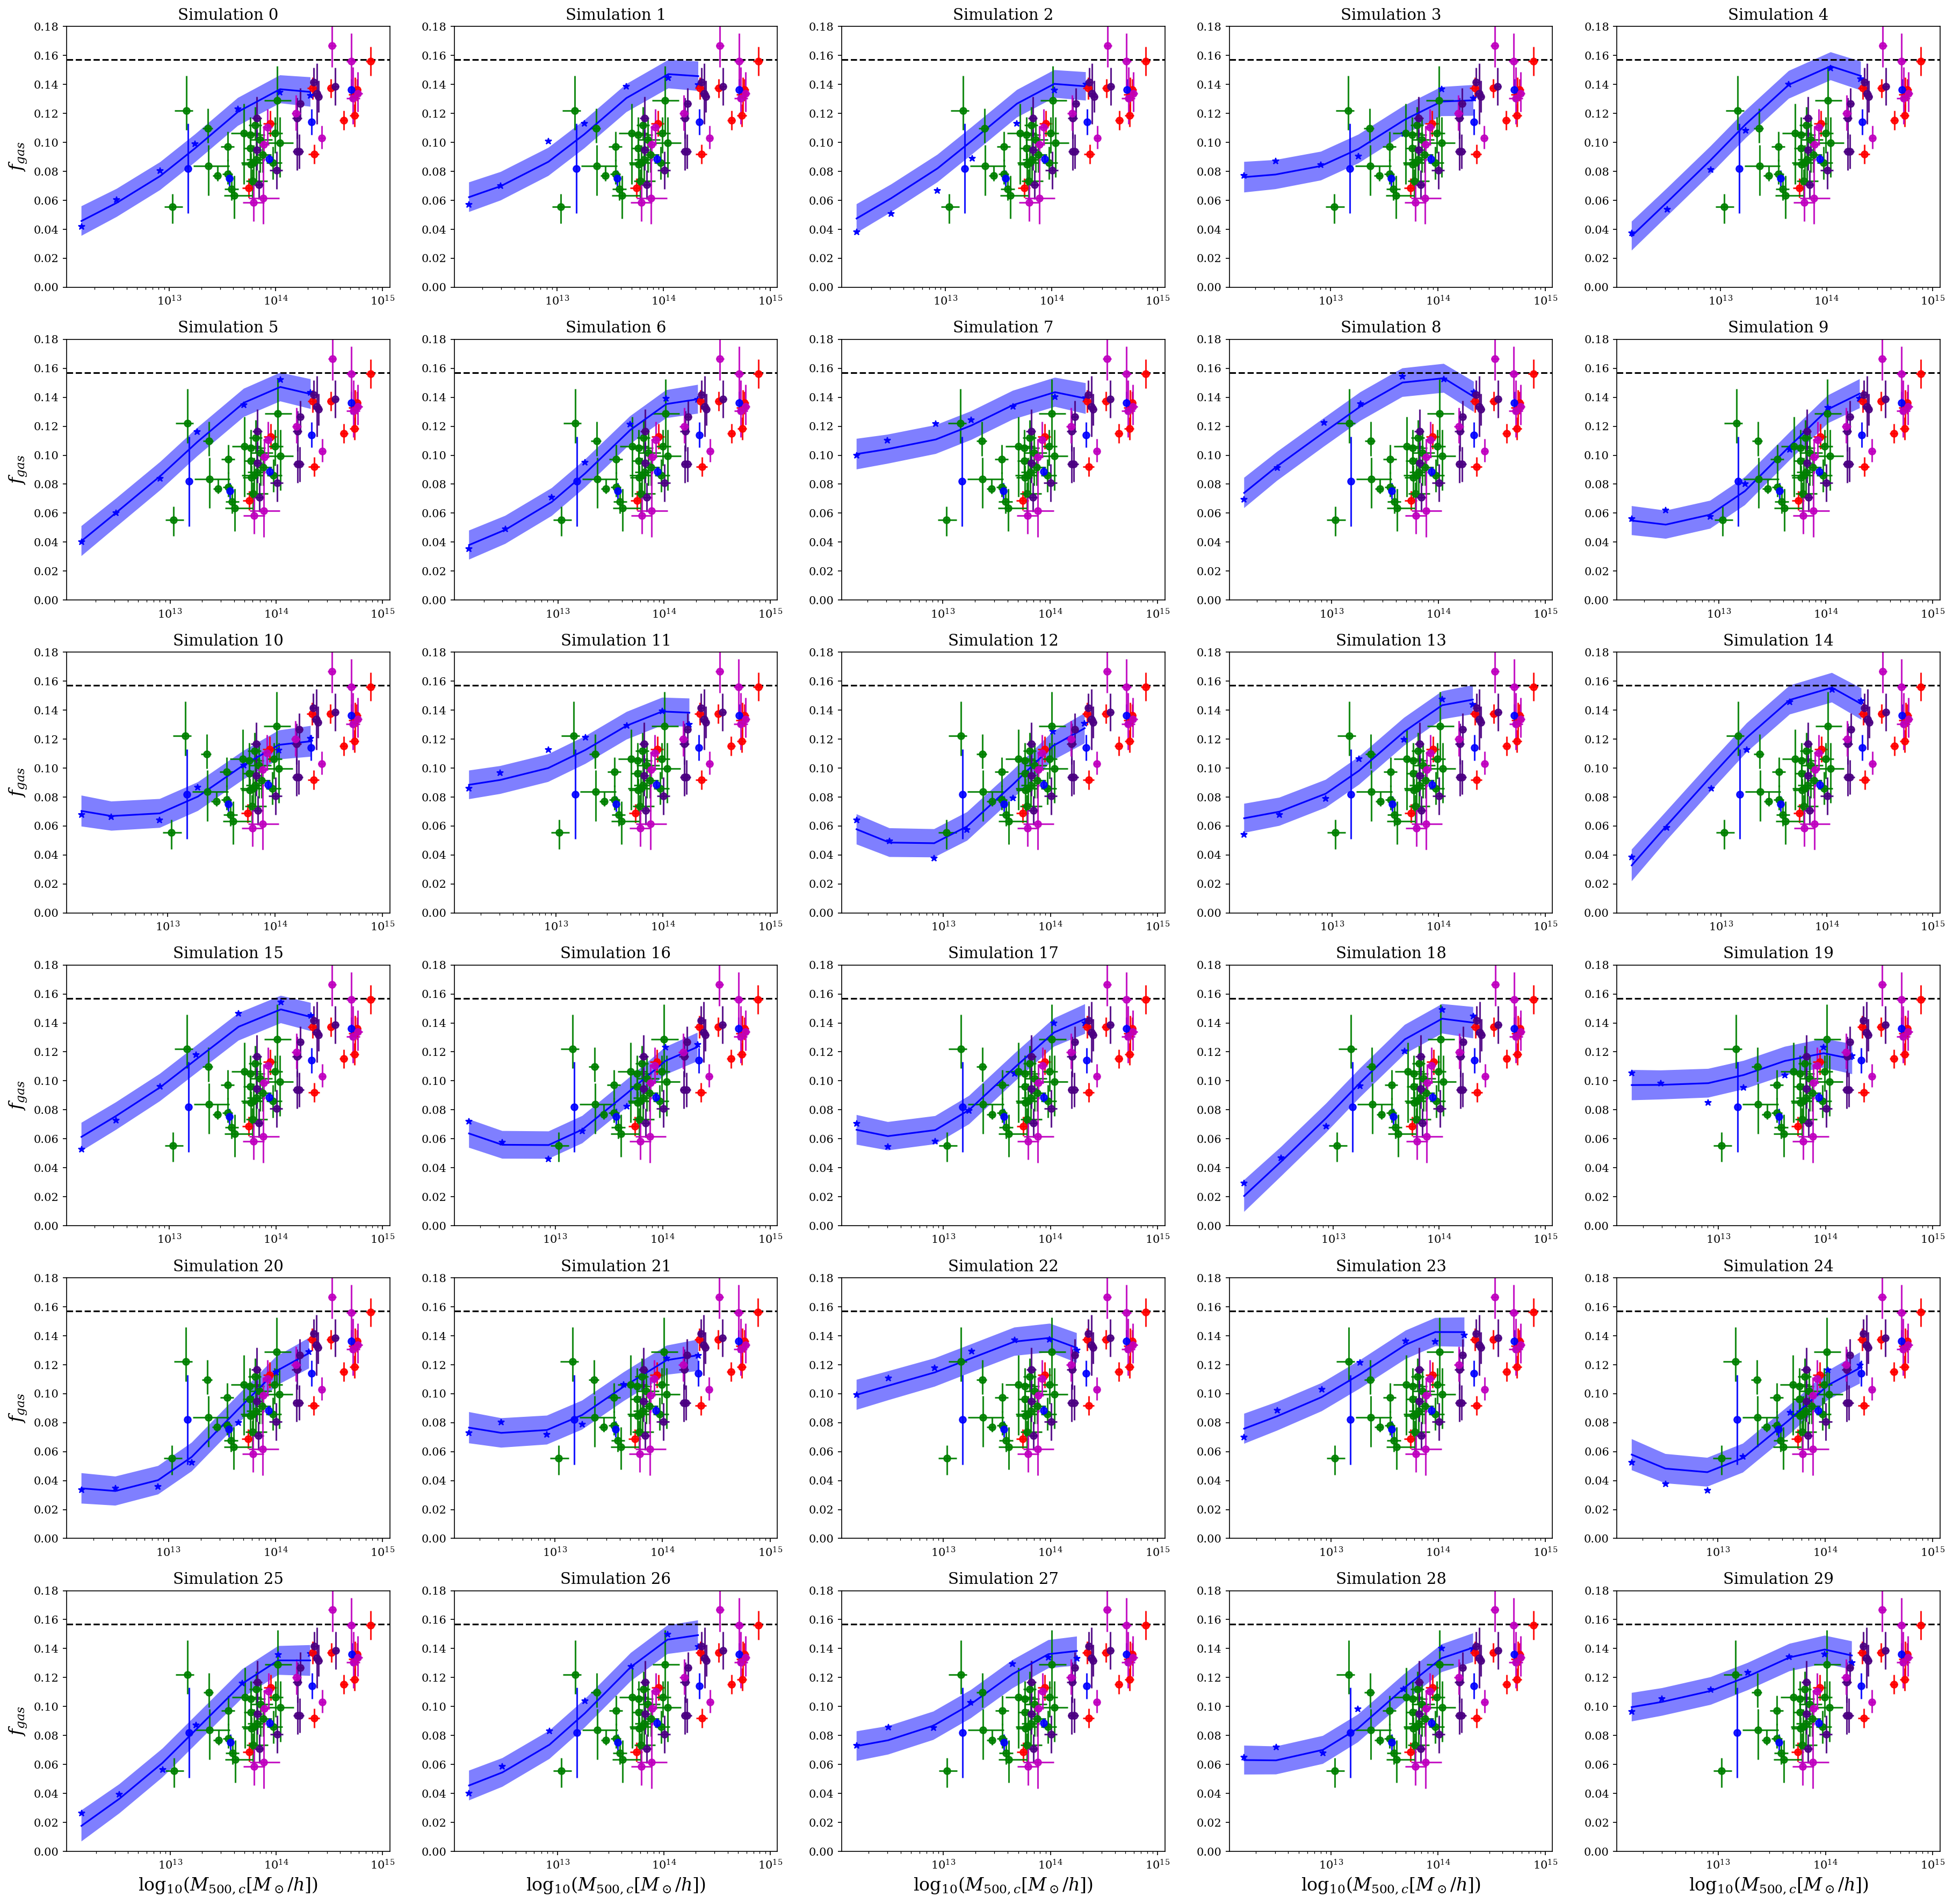

In [122]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(6, 5, figsize=(30, 30), dpi=150)

    for i in range(6):
        for j in range(5):
            if j==0:
                ax[i,j].set_ylabel(r"$f_{gas}$", fontsize=16)
            if i==5:
                ax[i,j].set_xlabel(r"$\log_{10}(M_{500,c} [M_\odot/h])$", fontsize=16)

            ax[i,j].set_title("Simulation {}".format(train_sel[5*i+j]), fontsize=14)
            ax[i,j].set_ylim(0, 0.18)
            ax[i,j].set_xscale("log")
    
            ax[i,j].axhline(y=0.157, color='k', ls='--', alpha=1)

            ax[i,j].errorbar(m500_V,f_gas_V,yerr=erf_gas_V,xerr=erm500_V,marker='o',c='red',ls='',label='Vikhlinin et al. 2006',alpha=0.9)
            ax[i,j].errorbar(m500_S,f_gas_S,yerr=(f_gas_Sm,f_gas_Sp),xerr=(m500_Sm,m500_Sp),marker='o',c='g',ls='',label='Sun et al. 2008',alpha=0.9)
            ax[i,j].errorbar(m500_G,f_gas_G,yerr=erf_gas_G, marker='o',c='blue',ls='',label='Giodini et al. 2009',alpha=0.9)
            ax[i,j].errorbar(m500,f_gas,yerr=erf_gas,xerr=erm500,marker='o',c='indigo',ls='',label='Gonzalez et al. 2013',alpha=0.9)
            ax[i,j].errorbar(m500_A,f_gas_A,yerr=(f_gas_Am,f_gas_Ap),xerr=(m500_Am,m500_Ap),marker='o',c='m',ls='',label='Arnaud et al. 2017',alpha=0.9)

            test_x = torch.asarray(pars(train_sel[5*i+j], np.log10(zoom_fgas[name_list[train_sel[5*i+j]]]['m500c'][0])), dtype=torch.float)
            observed_pred = likelihood_fgas(model_fgas(torch.asarray(test_x, dtype=torch.float)))
        
            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()
            # Plot training data as black stars
            ax[i,j].plot(zoom_fgas[name_list[train_sel[5*i+j]]]['m500c'][0], zoom_fgas[name_list[train_sel[5*i+j]]]['f_gas'][0], 'b*')

            # Plot predictive means as blue line
        #    for i in range(10):
        #        ax.plot(mstar_test, smf_test.sample().numpy(), 'b', ls='--', lw=0.5)
            ax[i,j].plot(10**(test_x[:,0]), observed_pred.mean.numpy(), 'b')

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(10**(test_x[:,0].numpy()), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)

# ax.set_xlabel('$M_*$')
# ax.set_ylabel('SMF')


In [75]:
param_means = np.array([np.mean(wind_en_or), np.mean(wind_vel_or), np.mean(rho_rec_or), 
                        np.mean(sf_ts_or), np.mean(ef_kin_or), np.mean(ef_high_or), np.mean(f_re_or)])
param_stds  = np.array([np.std(wind_en_or), np.std(wind_vel_or), np.std(rho_rec_or), 
                        np.std(sf_ts_or), np.std(ef_kin_or), np.std(ef_high_or), np.std(f_re_or)])

lower_bound = np.asarray([0.9,  3.7,  np.log10(0.005), 0.001135, np.log10(0.001), 0.05, 10, -np.inf, -np.inf])
upper_bound = np.asarray([14.4, 14.8, np.log10(0.5),   0.00454,  np.log10(2),     0.2,  40, np.inf, np.inf])

def prepare_theta(theta):

    theta_std = np.copy(theta)
    
    theta_std[0]  = (theta_std[0] - np.mean(wind_en_or)) / np.std(wind_en_or)
    theta_std[1]  = (theta_std[1] - np.mean(wind_vel_or)) / np.std(wind_vel_or)
    theta_std[2]  = (theta_std[2] - np.mean(rho_rec_or)) / np.std(rho_rec_or)
    theta_std[3]  = (theta_std[3] - np.mean(sf_ts_or)) / np.std(sf_ts_or)
    theta_std[4]  = (theta_std[4] - np.mean(ef_kin_or)) / np.std(ef_kin_or)
    theta_std[5]  = (theta_std[5] - np.mean(ef_high_or)) / np.std(ef_high_or)
    theta_std[6]  = (theta_std[6] - np.mean(f_re_or)) / np.std(f_re_or)

    return theta_std

# --- 2. THE JOINT LIKELIHOOD ---

def log_p(theta):
    # 1. Check for non-physical parameters (Prior check)
    # Define bounds for the 7 physical parameters (theta_1 to theta_7)
    lower_bounds = lower_bound
    upper_bounds = upper_bound
    if not (np.all(theta > lower_bounds) and np.all(theta < upper_bounds)):
        return -np.inf # Implements a flat prior
    else:
        # Prior on b_star
        prior_bstar = -0.5 * ( (theta[7]/0.14)**2 + np.log(2 * np.pi * 0.14**2) )

        # Prior on b_cv
        prior_bcv = -0.5 * ( ( (theta[8]-1)/0.06)**2 + np.log(2 * np.pi * 0.06**2) )

        return prior_bstar + prior_bcv

def log_likelihood_joint(theta, data_dict, models_dict, w_smf, w_fgas):
    """
    Joint likelihood for SMF and Gas Fractions.
    data_dict: contains 'mstar', 'smf_obs', 'smf_err', 'mhalo', 'fgas_obs', 'fgas_err', 'mhalo_err'
    models_dict: contains 'gp_smf', 'gp_fgas'
    """

    theta_std = prepare_theta(theta)
    
    # --- Part A: SMF Likelihood ---
    # Get the observational model
    GAMA_data = model_GAMA(GAMA_corr, theta[7], theta[8])

    obs_log_phi = GAMA_data[9:,1]
    obs_uncertainty = GAMA_data[9:,2]
    mstar = GAMA_data[9:,0]
    
    smf_input = np.hstack([mstar[:, None], np.repeat(theta_std[None, :7], len(mstar), axis=0)])
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_smf = models_dict['gp_smf'](torch.from_numpy(smf_input).float())
        mu_smf = pred_smf.mean.numpy()
        var_smf = pred_smf.variance.numpy() + data_dict['smf_err']**2
    
    lnL_smf = -0.5 * np.sum(((data_dict['smf_obs'] - mu_smf)**2 / var_smf) + np.log(2 * np.pi * var_smf))

    # --- Part B: Gas Fraction Likelihood ---
    mhalo = data_dict['mhalo']
    # Halo mass might also need normalization if your GP was trained on standardized M_h
    fgas_input = np.hstack([mhalo[:, None], np.repeat(theta_std[None, :7], len(mhalo), axis=0)])
    
    # To handle M_h uncertainty properly, we enable gradients for the slope calculation
    # If the GP is smooth, you can approximate this; here we use the predictive mean.
    x_gas_torch = torch.from_numpy(fgas_input).float().requires_grad_(True)
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_fgas = models_dict['gp_fgas'](x_gas_torch)
        mu_fgas = pred_fgas.mean
        var_fgas_emu = pred_fgas.variance.detach().numpy()
        
        # # Calculate slope df/dmhalo to propagate M_halo uncertainty
        # # This is the 'errors-in-variables' correction
        # mu_fgas.sum().backward()
        # slope = x_gas_torch.grad[:, 0].numpy() # Derivative w.r.t the first column (M_h)
        
    mu_fgas = mu_fgas.detach().numpy()
    
    # Total variance = GP_var + Obs_fgas_var + (slope * Obs_Mhalo_var)^2
    var_fgas_total = var_fgas_emu + data_dict['fgas_err']**2 #+ (slope * data_dict['mhalo_err'])**2
    
    lnL_fgas = -0.5 * np.sum(((data_dict['fgas_obs'] - mu_fgas)**2 / var_fgas_total) + np.log(2 * np.pi * var_fgas_total))

    # --- Part C: Combined ---
    total_lnL = w_smf * lnL_smf + w_fgas * lnL_fgas + log_p(theta)
    
    return total_lnL if np.isfinite(total_lnL) else -np.inf

In [56]:
# --- 1. SET UP DATA AND MODELS ---

# Observations for SMF
data_dict = {
    'mstar':     np.array(GAMA_corr[9:,0]), # Mass bins
    'smf_obs':   np.array(GAMA_corr[9:,1]), # log10(Phi)
    'smf_err':   np.array(GAMA[9:,2]), # Uncertainty in log10(Phi)
    
    # Observations for Gas Fractions
    'mhalo':     m500_pp, # Halo mass bins (input)
    'fgas_obs':  fgas_pp, # Measured gas fraction
    'fgas_err':  err_pp, # Uncertainty in gas fraction (y-axis)
    'mhalo_err': np.array(np.zeros_like(m500_pp))  # Uncertainty in halo mass (x-axis)
}

# Wrap models
models_dict = {
    'gp_smf':  model_smf, # Your first trained GP
    'gp_fgas': model_fgas # Your second trained GP
}

# Ensure models are in evaluation mode
for m in models_dict.values():
    m.eval()

In [76]:
import emcee

def run_MCMC(w_smf, w_fgas):

    ndim = 9
    nwalkers = 3 * ndim

    # Initialize walkers within the physical bounds (lower_bound, upper_bound)
    # We start them in a small ball around a reasonable central guess
    p0_start = np.asarray([np.mean(wind_en_or), np.mean(wind_vel_or), np.mean(rho_rec_or), np.mean(sf_ts_or),\
                        np.mean(ef_kin_or), np.mean(ef_high_or), np.mean(f_re_or), 0, 1])
    p0 = p0_start + 1e-4 * np.random.randn(nwalkers, ndim)

    # Ensure initial positions are actually within bounds
    p0 = np.clip(p0, lower_bound + 1e-5, upper_bound - 1e-5)

    # Initialize the sampler
    sampler = emcee.EnsembleSampler(
        nwalkers, 
        ndim, 
        log_likelihood_joint, # Our joint function
        args=(data_dict, models_dict, w_smf, w_fgas)
    )

    # --- RUNNING MCMC WITH CONVERGENCE CHECK ---
    print("Starting MCMC run with convergence monitoring...")

    # Initialize variables
    max_n = 50000        # Maximum number of steps to allow
    autocorr_tol = 0.01  # Tolerance for fractional change in tau (e.g., 1%)
    min_steps = 1000     # Minimum number of steps before checking tau
    index = 0
    old_tau = np.inf

    # The main loop that runs the sampler until convergence criteria are met
    for sample in sampler.sample(p0, iterations=max_n, progress=False):
        
        # Only check for convergence every 'check_interval' steps
        check_interval = 100
        if sampler.iteration % check_interval:
            continue

        index += 1
        
        # 1. Estimate the autocorrelation time (tau)
        # The default 'c' argument is 50, meaning it requires at least 50 independent samples
        # to estimate tau robustly.
        try:
            # Use discard=0 since we are checking the full chain so far
            tau = sampler.get_autocorr_time(tol=0, discard=0) 
        except emcee.autocorr.AutocorrError:
            # Not enough samples yet to estimate tau. Keep sampling.
            print(f"Step {sampler.iteration}: Not enough samples to estimate tau. Continuing...")
            continue

        # Take the maximum tau across all dimensions
        current_tau = np.max(tau)
        
        # 2. Check for burn-in and chain length convergence
        # We require the chain length to be at least 50 times the estimated tau
        converged = sampler.iteration > (50 * current_tau)

        # 3. Check for stabilization of tau
        # We require the estimated tau to have stabilized (change by less than the tolerance)
        stabilized = np.all(np.abs(old_tau - current_tau) / current_tau < autocorr_tol)
        
        print(f"Step {sampler.iteration}: Max tau = {current_tau:.2f}. Old tau = {old_tau:.2f}. Stabilized: {stabilized}.")

        # Update tau for the next check
        old_tau = current_tau
        
        # Break if both conditions are met AND we are past the minimum steps
        if converged and stabilized and sampler.iteration >= min_steps:
            print("MCMC converged!")
            break

    return sampler

In [106]:
# --- Joint SMF & fgas contraints -----
# sampler = run_MCMC(1, 1)
burnin = int(2 * np.max(sampler.get_autocorr_time(tol=0)))
flat_samples = sampler.get_chain(discard=burnin, flat=True)
log_l = sampler.get_log_prob(discard=burnin, flat=True)

In [104]:
# # --- Just SMF
# sampler_smf = run_MCMC(1, 0)
burnin = int(2 * np.max(sampler_smf.get_autocorr_time(tol=0)))
smf_samples = sampler_smf.get_chain(discard=burnin, flat=True)
log_smf = sampler_smf.get_log_prob(discard=burnin, flat=True)

In [105]:
# --- Just fgas ----- 
# sampler_fgas = run_MCMC(0, 1)
burnin = int(2 * np.max(sampler_fgas.get_autocorr_time(tol=0)))
fgas_samples = sampler_fgas.get_chain(discard=burnin, flat=True)
log_fgas = sampler_fgas.get_log_prob(discard=burnin, flat=True)

In [59]:
param_names = ['Wind Energy', 'Wind Vel', 'Recoupling Factor',\
     'SFR Timescale', 'Radio Feedback', 'Black Hole Feedback', 'Reorientation Factor', 'b_star', 'b_cv']

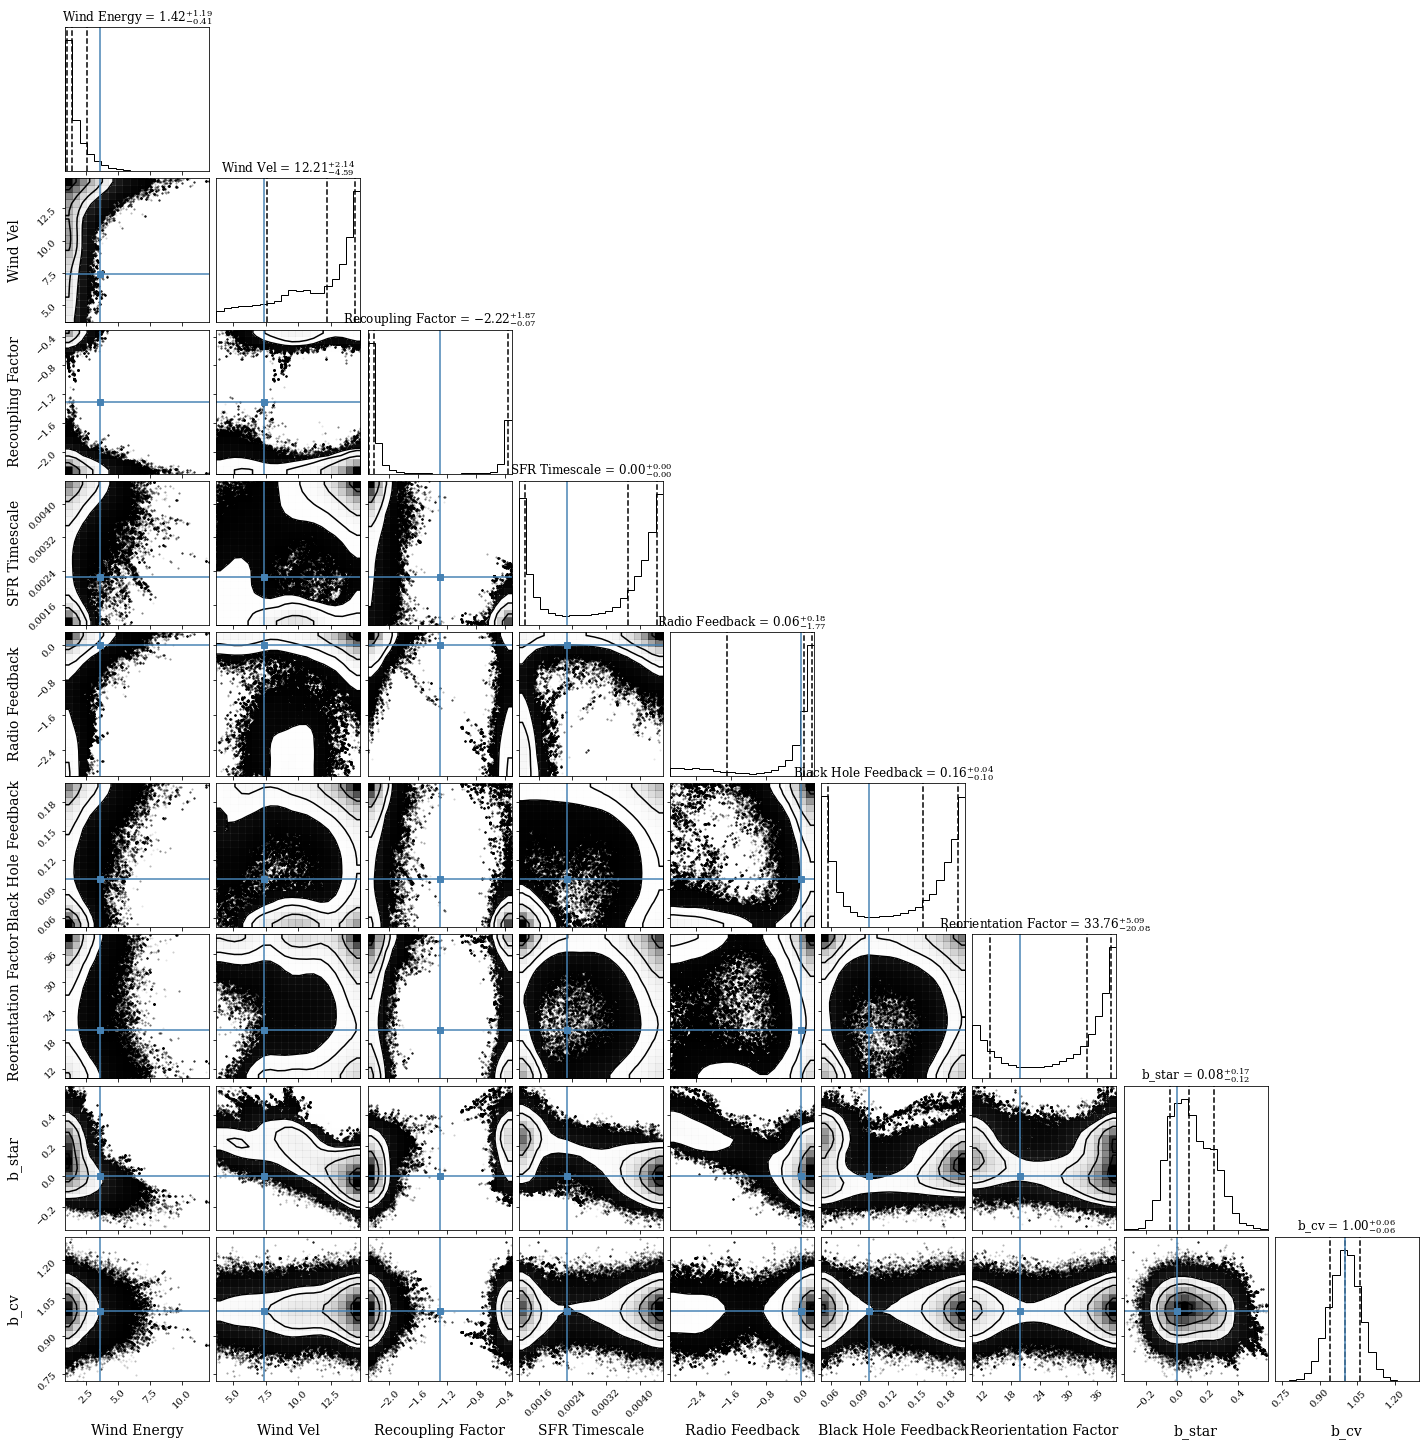


Summary Statistics (Median and 1-sigma uncertainty):
	Wind Energy = 1.42294_{-0.40709}^{+1.19044}
	Wind Vel = 12.21207_{-4.59440}^{+2.13783}
	Recoupling Factor = -2.21757_{-0.06546}^{+1.86616}
	SFR Timescale = 0.00372_{-0.00243}^{+0.00067}
	Radio Feedback = 0.06481_{-1.76508}^{+0.18226}
	Black Hole Feedback = 0.15554_{-0.09865}^{+0.03732}
	Reorientation Factor = 33.76048_{-20.07958}^{+5.09350}
	b_star = 0.07769_{-0.12126}^{+0.16739}
	b_cv = 1.00216_{-0.06238}^{+0.05968}


In [98]:
# Generate the corner plot 
fig = corner.corner(
    flat_samples, 
    labels=param_names, 
    label_kwargs={"fontsize": 14},
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12},
    smooth=True,
    truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30], 0, 1])
)

plt.show()

# --- Print Summary Statistics ---
print("\nSummary Statistics (Median and 1-sigma uncertainty):")
for i, name in enumerate(param_names):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\t{0} = {1:.5f}_{{-{2:.5f}}}^{{+{3:.5f}}}"
    txt = txt.format(name, mcmc[1], q[0], q[1])
    print(txt)

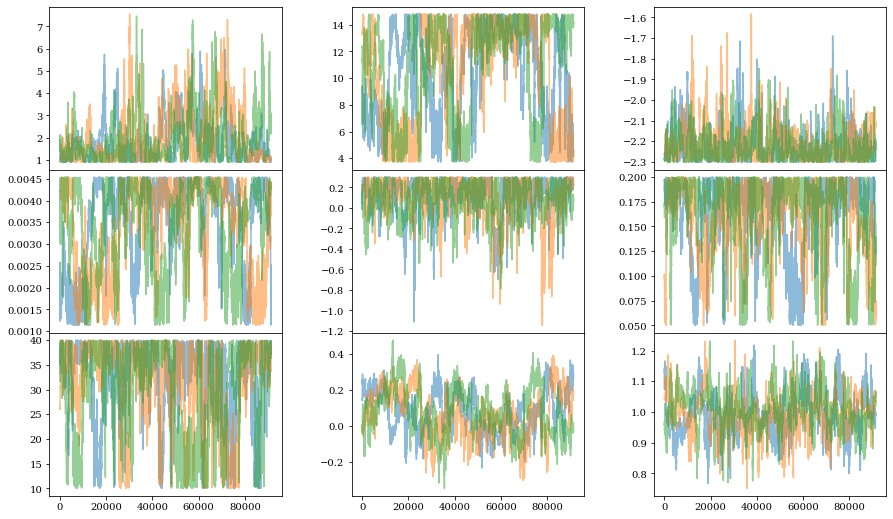

In [129]:
fig, ax = plt.subplots(3, 3, figsize=(15, 9))

plt.subplots_adjust(wspace=0.3, hspace=0.0)

samples = sampler.get_chain(discard=burnin, flat=False)

for i in range(3):
    for j in range(3):
        ax[i,j].plot(samples[:,0,3*i+j], alpha=0.5, ms=0.1, color='C0')
        ax[i,j].plot(samples[:,1,3*i+j], alpha=0.5, ms=0.1, color='C1')
        ax[i,j].plot(samples[:,2,3*i+j], alpha=0.5, ms=0.1, color='C2')

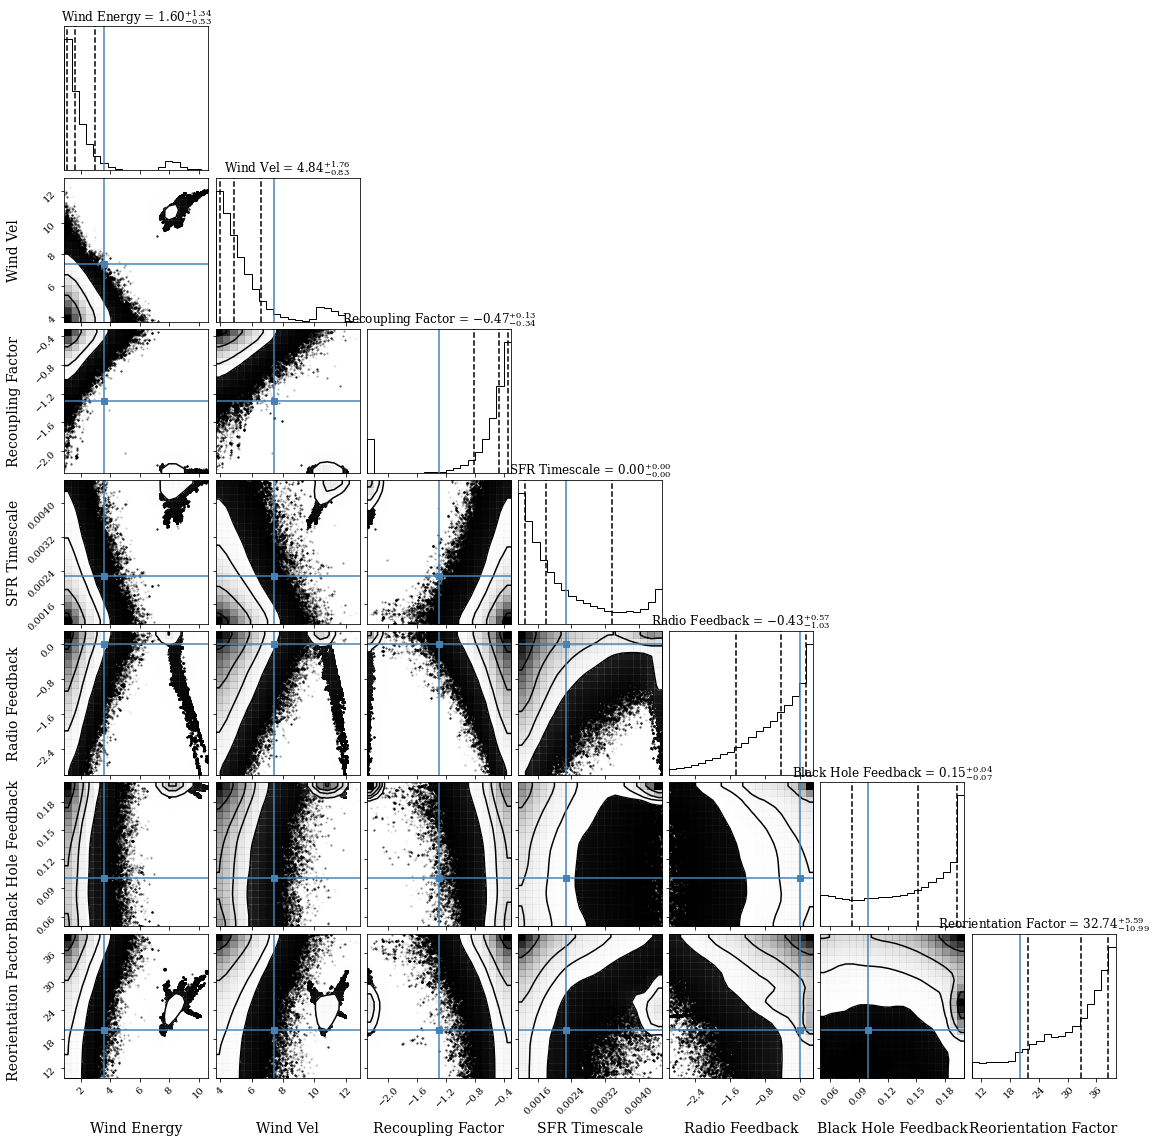


Summary Statistics (Median and 1-sigma uncertainty):
	Wind Energy = 1.60112_{-0.52734}^{+1.33957}
	Wind Vel = 4.84355_{-0.83224}^{+1.75609}
	Recoupling Factor = -0.47113_{-0.33919}^{+0.12682}
	SFR Timescale = 0.00180_{-0.00051}^{+0.00156}
	Radio Feedback = -0.42929_{-1.03027}^{+0.57017}
	Black Hole Feedback = 0.15142_{-0.06836}^{+0.04136}
	Reorientation Factor = 32.73542_{-10.99034}^{+5.59371}


In [100]:
# Generate the corner plot 
fig = corner.corner(
    fgas_samples[:,:7], 
    labels=param_names[:7], 
    label_kwargs={"fontsize": 14},
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12},
    smooth=True,
    truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])
)

plt.show()

# --- Print Summary Statistics ---
print("\nSummary Statistics (Median and 1-sigma uncertainty):")
for i, name in enumerate(param_names[:7]):
    mcmc = np.percentile(fgas_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\t{0} = {1:.5f}_{{-{2:.5f}}}^{{+{3:.5f}}}"
    txt = txt.format(name, mcmc[1], q[0], q[1])
    print(txt)

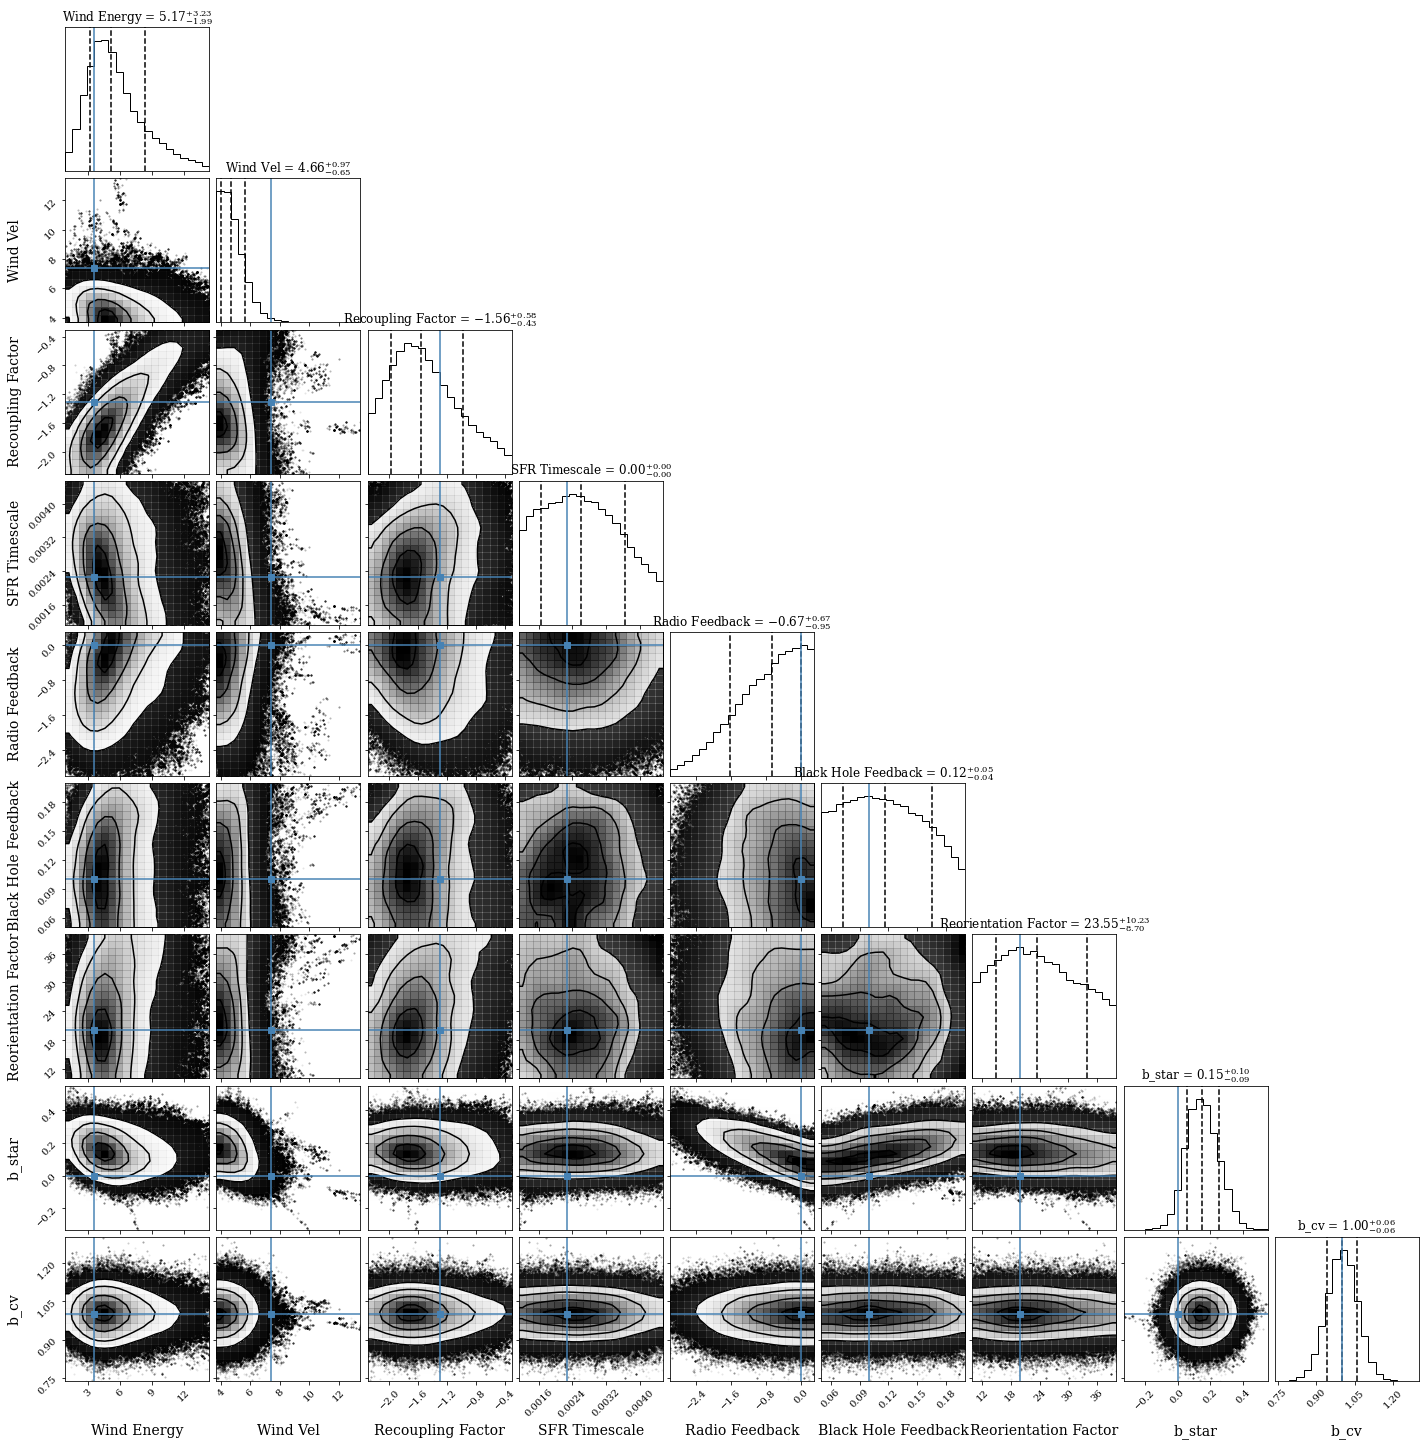


Summary Statistics (Median and 1-sigma uncertainty):
	Wind Energy = 5.17090_{-1.98828}^{+3.23458}
	Wind Vel = 4.65714_{-0.64559}^{+0.96813}
	Recoupling Factor = -1.55513_{-0.42687}^{+0.57637}
	SFR Timescale = 0.00260_{-0.00094}^{+0.00104}
	Radio Feedback = -0.66931_{-0.94614}^{+0.66987}
	Black Hole Feedback = 0.11690_{-0.04428}^{+0.04892}
	Reorientation Factor = 23.54630_{-8.69888}^{+10.22682}
	b_star = 0.14822_{-0.09198}^{+0.10322}
	b_cv = 1.00201_{-0.05996}^{+0.05833}


In [101]:
# Generate the corner plot 
fig = corner.corner(
    smf_samples, 
    labels=param_names, 
    label_kwargs={"fontsize": 14},
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12},
    smooth=True,
    truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30], 0, 1])
)

plt.show()

# --- Print Summary Statistics ---
print("\nSummary Statistics (Median and 1-sigma uncertainty):")
for i, name in enumerate(param_names):
    mcmc = np.percentile(smf_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\t{0} = {1:.5f}_{{-{2:.5f}}}^{{+{3:.5f}}}"
    txt = txt.format(name, mcmc[1], q[0], q[1])
    print(txt)

In [134]:
lower_bound = np.asarray([0.0,  0.0,  np.log10(0.005/100), 0.001135, np.log10(0.001), 0.05, 10, -np.inf, -np.inf])
upper_bound = np.asarray([14.4, 14.8, np.log10(0.5),       0.00454,  np.log10(2*100), 0.2,  40, np.inf,  np.inf])

sampler_ext = run_MCMC(1, 1)
burnin = int(2 * np.max(sampler_ext.get_autocorr_time(tol=0)))
samples_ext = sampler_ext.get_chain(discard=burnin, flat=True)
log_l_ext = sampler_ext.get_log_prob(discard=burnin, flat=True)

Starting MCMC run with convergence monitoring...
Step 100: Max tau = 12.30. Old tau = inf. Stabilized: False.


/tmp/ipykernel_188210/3630714054.py:36: RuntimeWarning: invalid value encountered in log10
  GAMA_corr[:,1] = GAMA_corr[:,1] + np.log10(b_cv)


Step 200: Max tau = 25.80. Old tau = 12.30. Stabilized: False.
Step 300: Max tau = 39.81. Old tau = 25.80. Stabilized: False.
Step 400: Max tau = 51.43. Old tau = 39.81. Stabilized: False.
Step 500: Max tau = 63.38. Old tau = 51.43. Stabilized: False.
Step 600: Max tau = 76.27. Old tau = 63.38. Stabilized: False.
Step 700: Max tau = 85.47. Old tau = 76.27. Stabilized: False.
Step 800: Max tau = 96.47. Old tau = 85.47. Stabilized: False.
Step 900: Max tau = 106.12. Old tau = 96.47. Stabilized: False.
Step 1000: Max tau = 116.02. Old tau = 106.12. Stabilized: False.
Step 1100: Max tau = 123.88. Old tau = 116.02. Stabilized: False.
Step 1200: Max tau = 130.20. Old tau = 123.88. Stabilized: False.
Step 1300: Max tau = 136.35. Old tau = 130.20. Stabilized: False.
Step 1400: Max tau = 143.33. Old tau = 136.35. Stabilized: False.
Step 1500: Max tau = 149.14. Old tau = 143.33. Stabilized: False.
Step 1600: Max tau = 152.49. Old tau = 149.14. Stabilized: False.
Step 1700: Max tau = 157.78. Old 

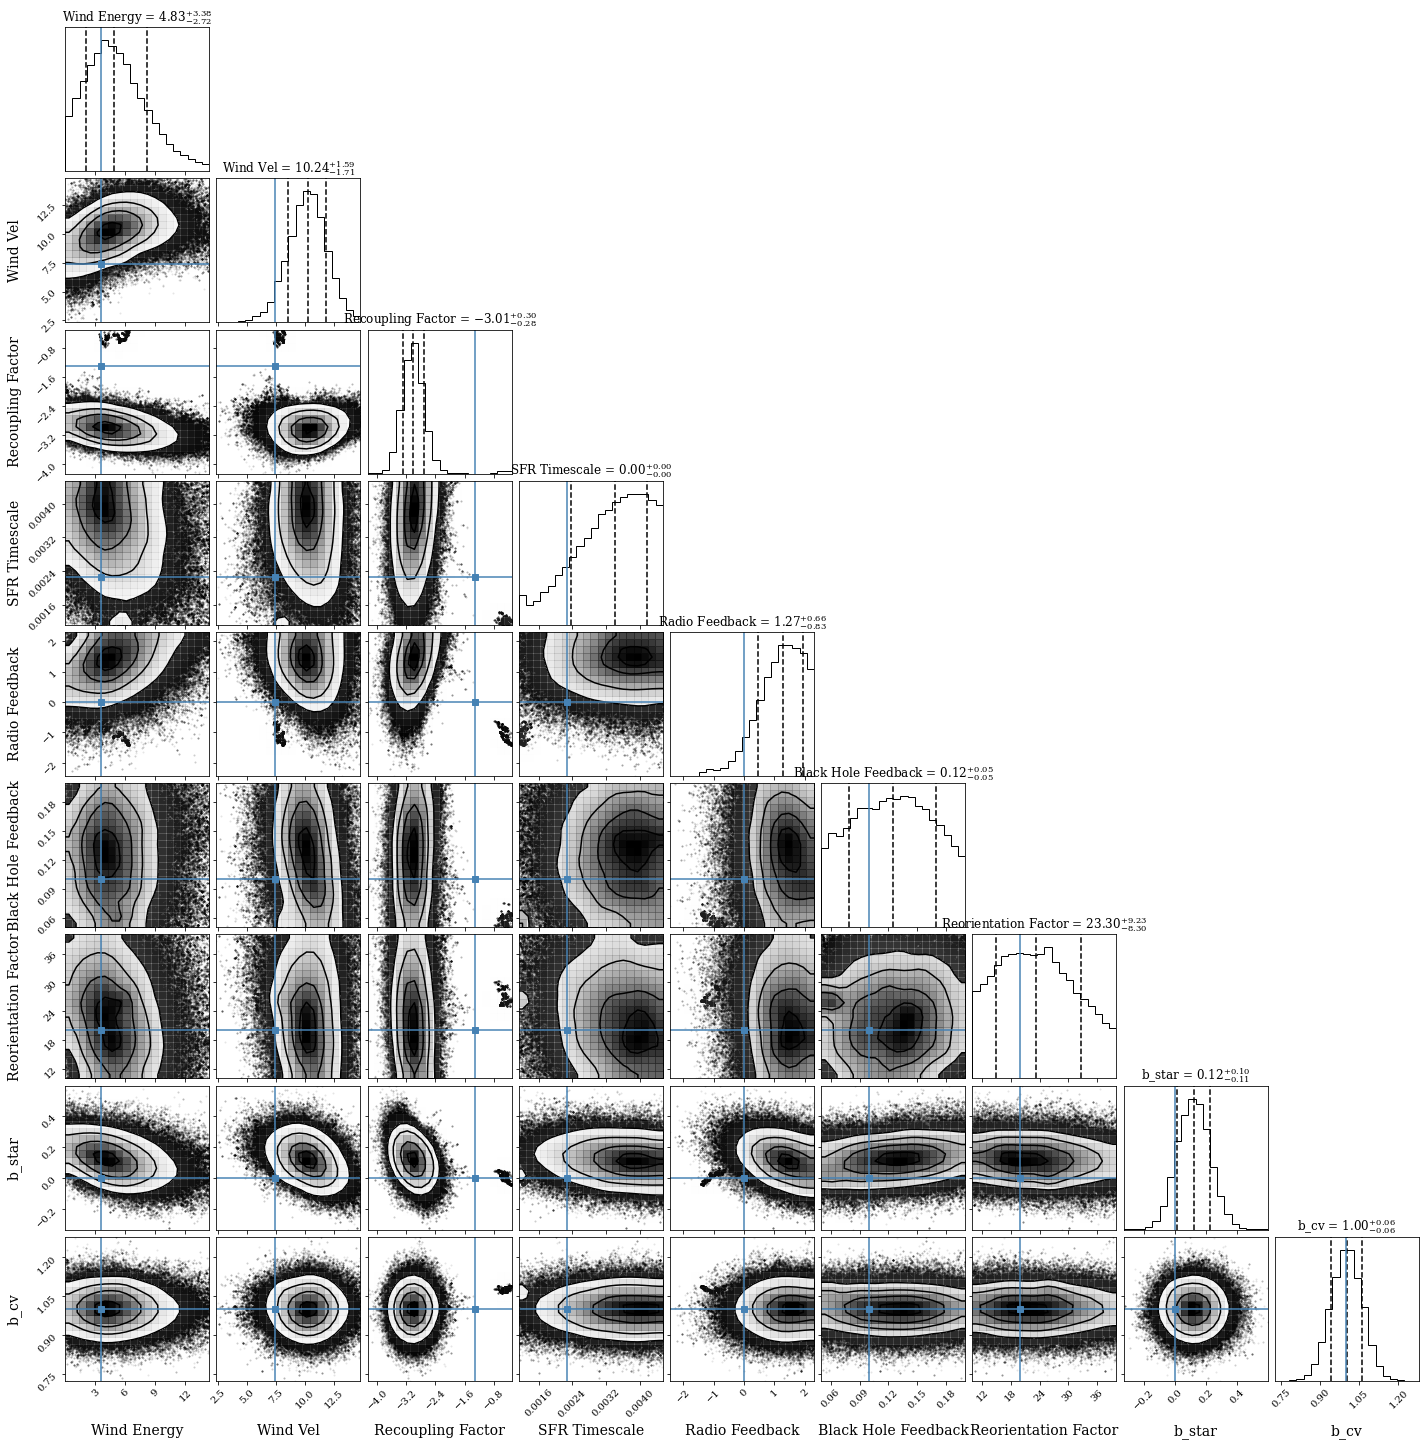


Summary Statistics (Median and 1-sigma uncertainty):
	Wind Energy = 4.82502_{-2.71769}^{+3.38124}
	Wind Vel = 10.23919_{-1.70657}^{+1.59017}
	Recoupling Factor = -3.01280_{-0.28412}^{+0.29505}
	SFR Timescale = 0.00340_{-0.00103}^{+0.00076}
	Radio Feedback = 1.27410_{-0.82874}^{+0.66336}
	Black Hole Feedback = 0.12495_{-0.04618}^{+0.04502}
	Reorientation Factor = 23.29667_{-8.30013}^{+9.22986}
	b_star = 0.12081_{-0.10505}^{+0.10451}
	b_cv = 1.00161_{-0.06065}^{+0.06031}


In [135]:
# Generate the corner plot 
fig = corner.corner(
    samples_ext,
    labels=param_names,
    label_kwargs={"fontsize": 14},
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 12},
    smooth=True,
    truths = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30], 0, 1])
)

plt.show()

# --- Print Summary Statistics ---
print("\nSummary Statistics (Median and 1-sigma uncertainty):")
for i, name in enumerate(param_names):
    mcmc = np.percentile(samples_ext[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\t{0} = {1:.5f}_{{-{2:.5f}}}^{{+{3:.5f}}}"
    txt = txt.format(name, mcmc[1], q[0], q[1])
    print(txt)

In [102]:
# Assuming 'prepare_theta', 'mass_bins', 'means', and 'stds' are defined in the global scope 
# as in the previous, corrected response.

def get_gp_prediction(theta_original, mstar, gp_model):
    """
    Takes a set of 7 parameters (in original physical units) and returns 
    the predicted GP mean and variance for the full SMF curve (across all mstar bins).
    """
    
    # 1. Standardize theta (using the globally defined prepare_theta function)
    theta_standardized = prepare_theta(theta_original)
    
    # 2. Construct 8D input vector (mstar and standardized theta)
    N_mass_bins = len(mstar)
    theta_vector = np.repeat(theta_standardized[np.newaxis, :], N_mass_bins, axis=0)
    
    # Full 8D input: [log10(M*), theta_1_std, ..., theta_7_std]
    gp_input = np.hstack([
        mstar[:, np.newaxis], # (N_mass_bins, 1)
        theta_vector          # (N_mass_bins, 7)
    ]) 

    # 3. Predict with gpytorch
    x_star = torch.from_numpy(gp_input).float() 
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictive_dist = gp_model(x_star) 
        
    mu_pred = predictive_dist.mean.numpy()         # Predicted mean SMF curve
    var_emulator = predictive_dist.variance.numpy() # GP intrinsic variance
    
    return mu_pred, var_emulator

In [103]:
fiducial_dict = {
    'smf_mstar': np.log10(zoom_smf['fiducial']['mstar'][0]),
    'smf_phi': np.log10(zoom_smf['fiducial']['smf'][0]),
    'fgas_mhalo': np.log10(zoom_fgas['fiducial']['m500c'][0]),
    'fgas_val': zoom_fgas['fiducial']['f_gas'][0]
}

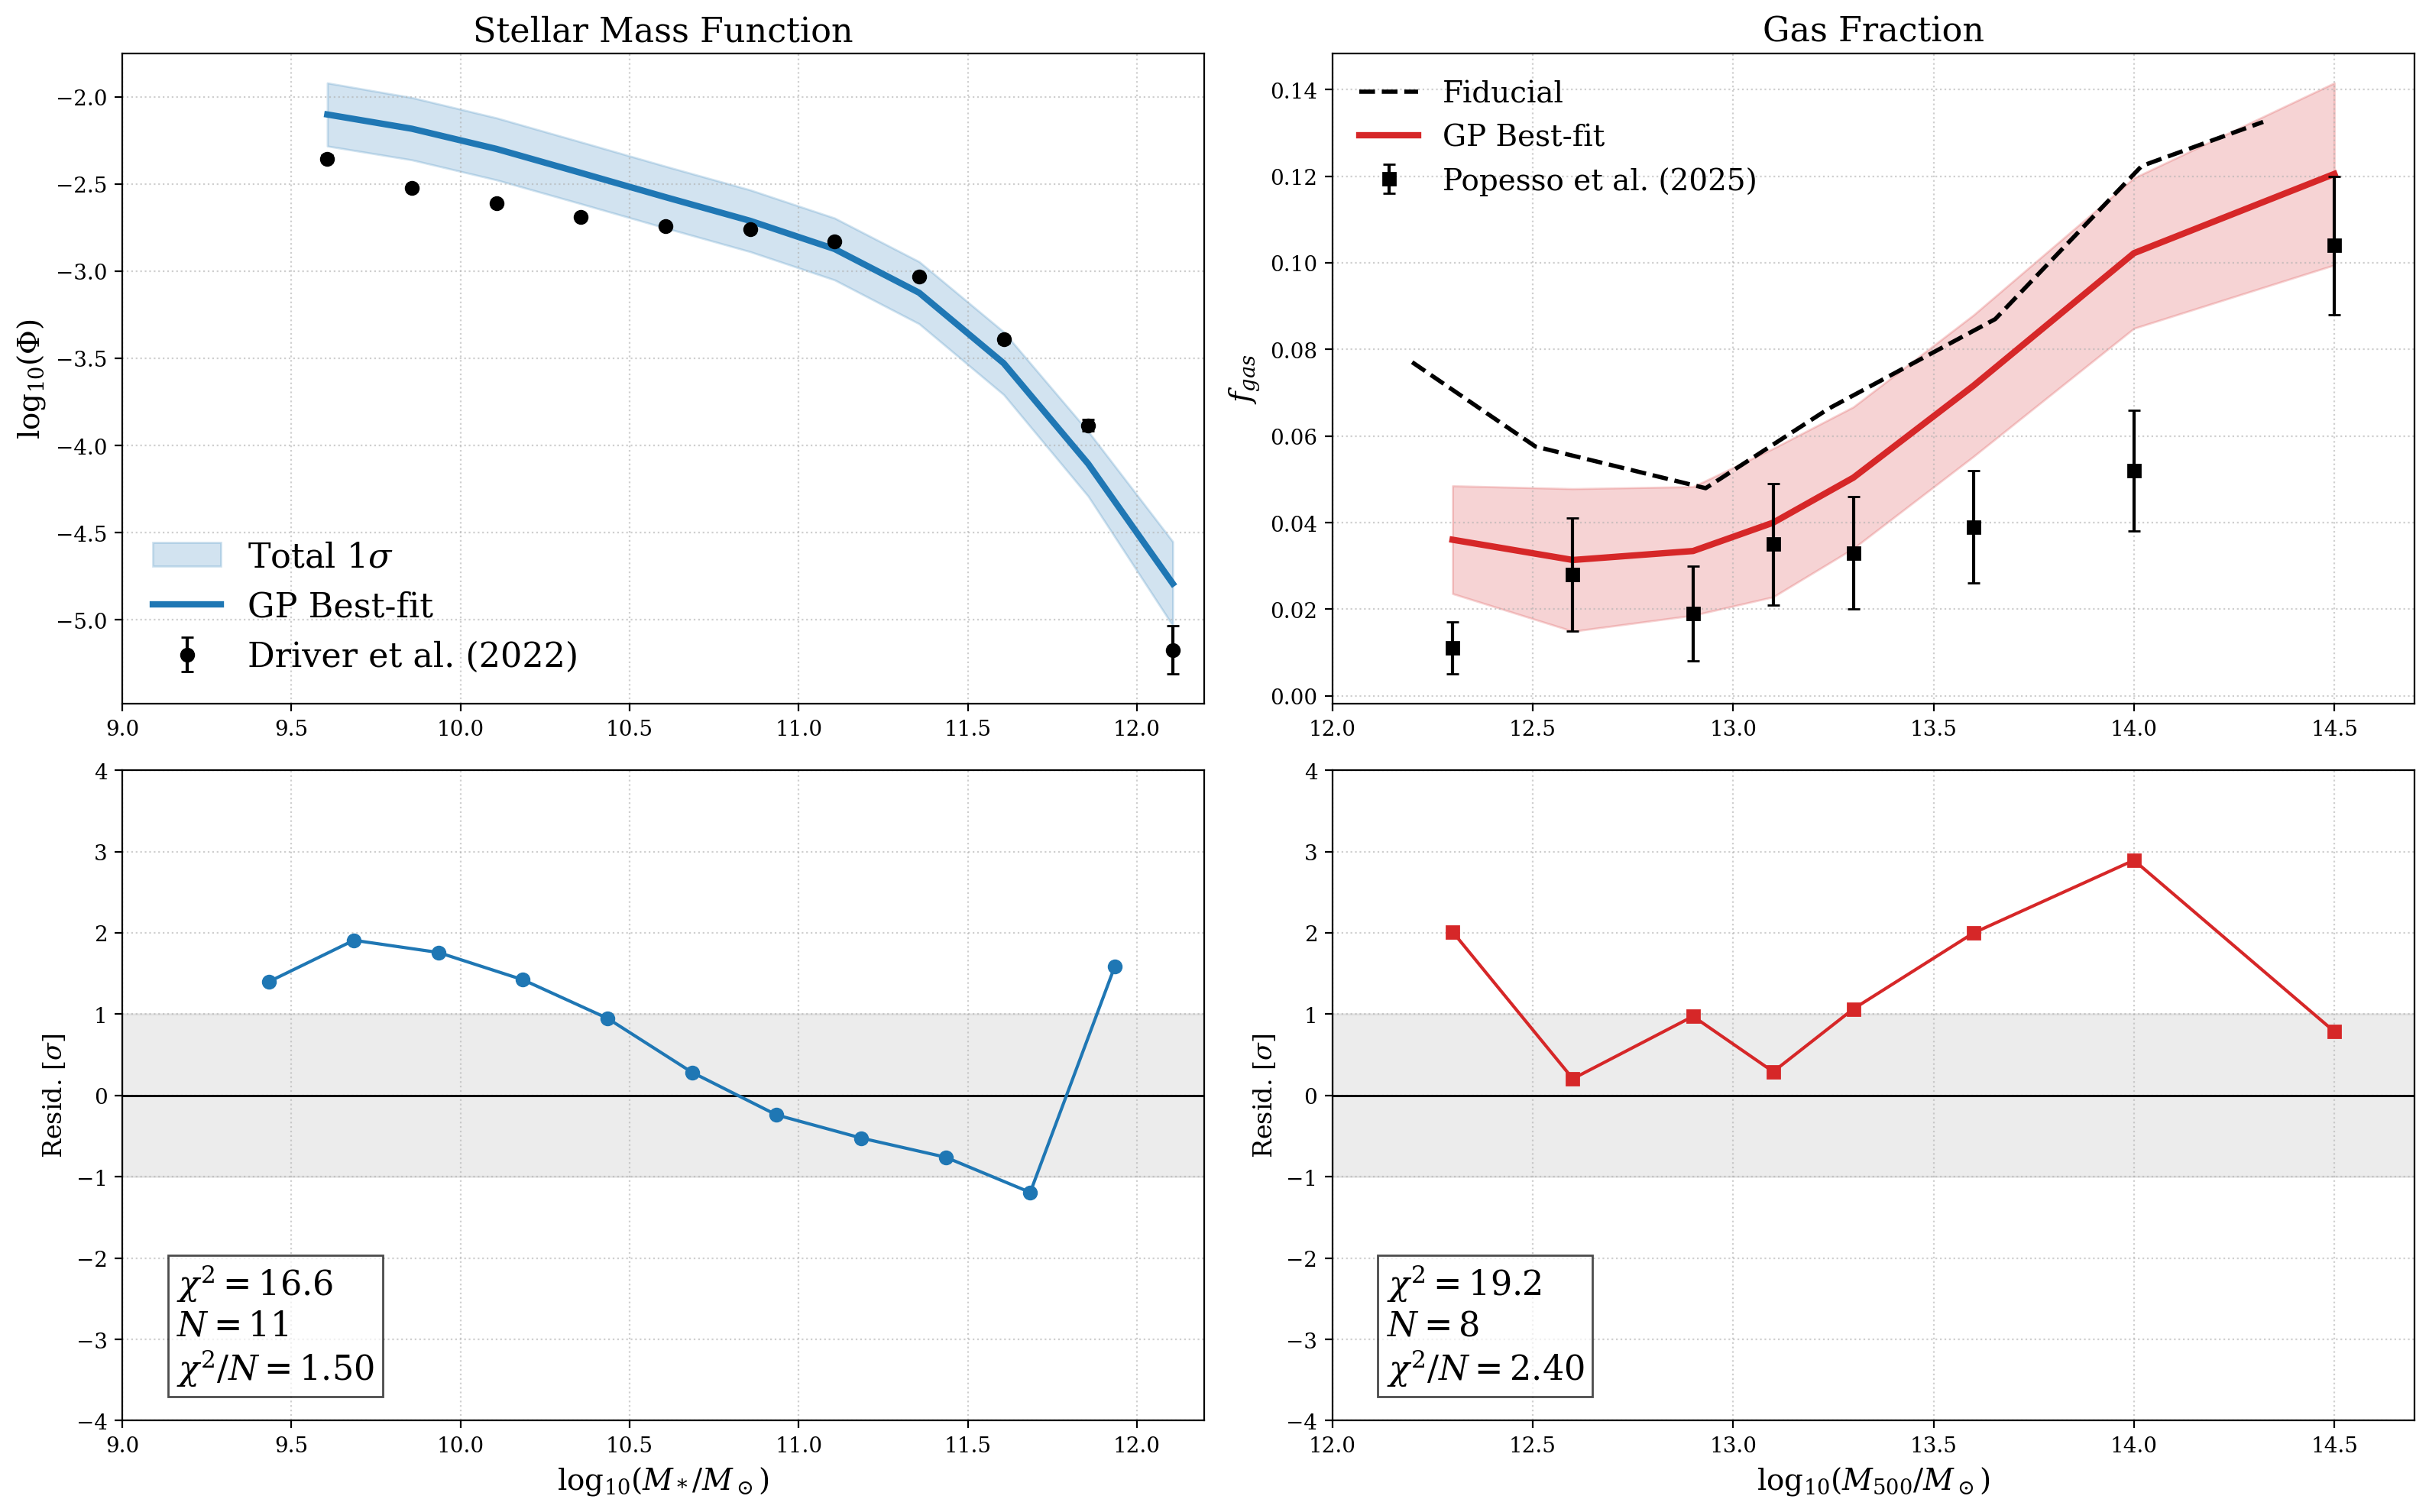

In [108]:
# 1. Best-Fit Calculations
# bf_theta = np.median(flat_samples[:,:7], axis=0)
bf_theta = flat_samples[np.argmax(log_l)]

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
# ax_m1.plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
#                 'k--', lw=2, label='Fiducial')
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

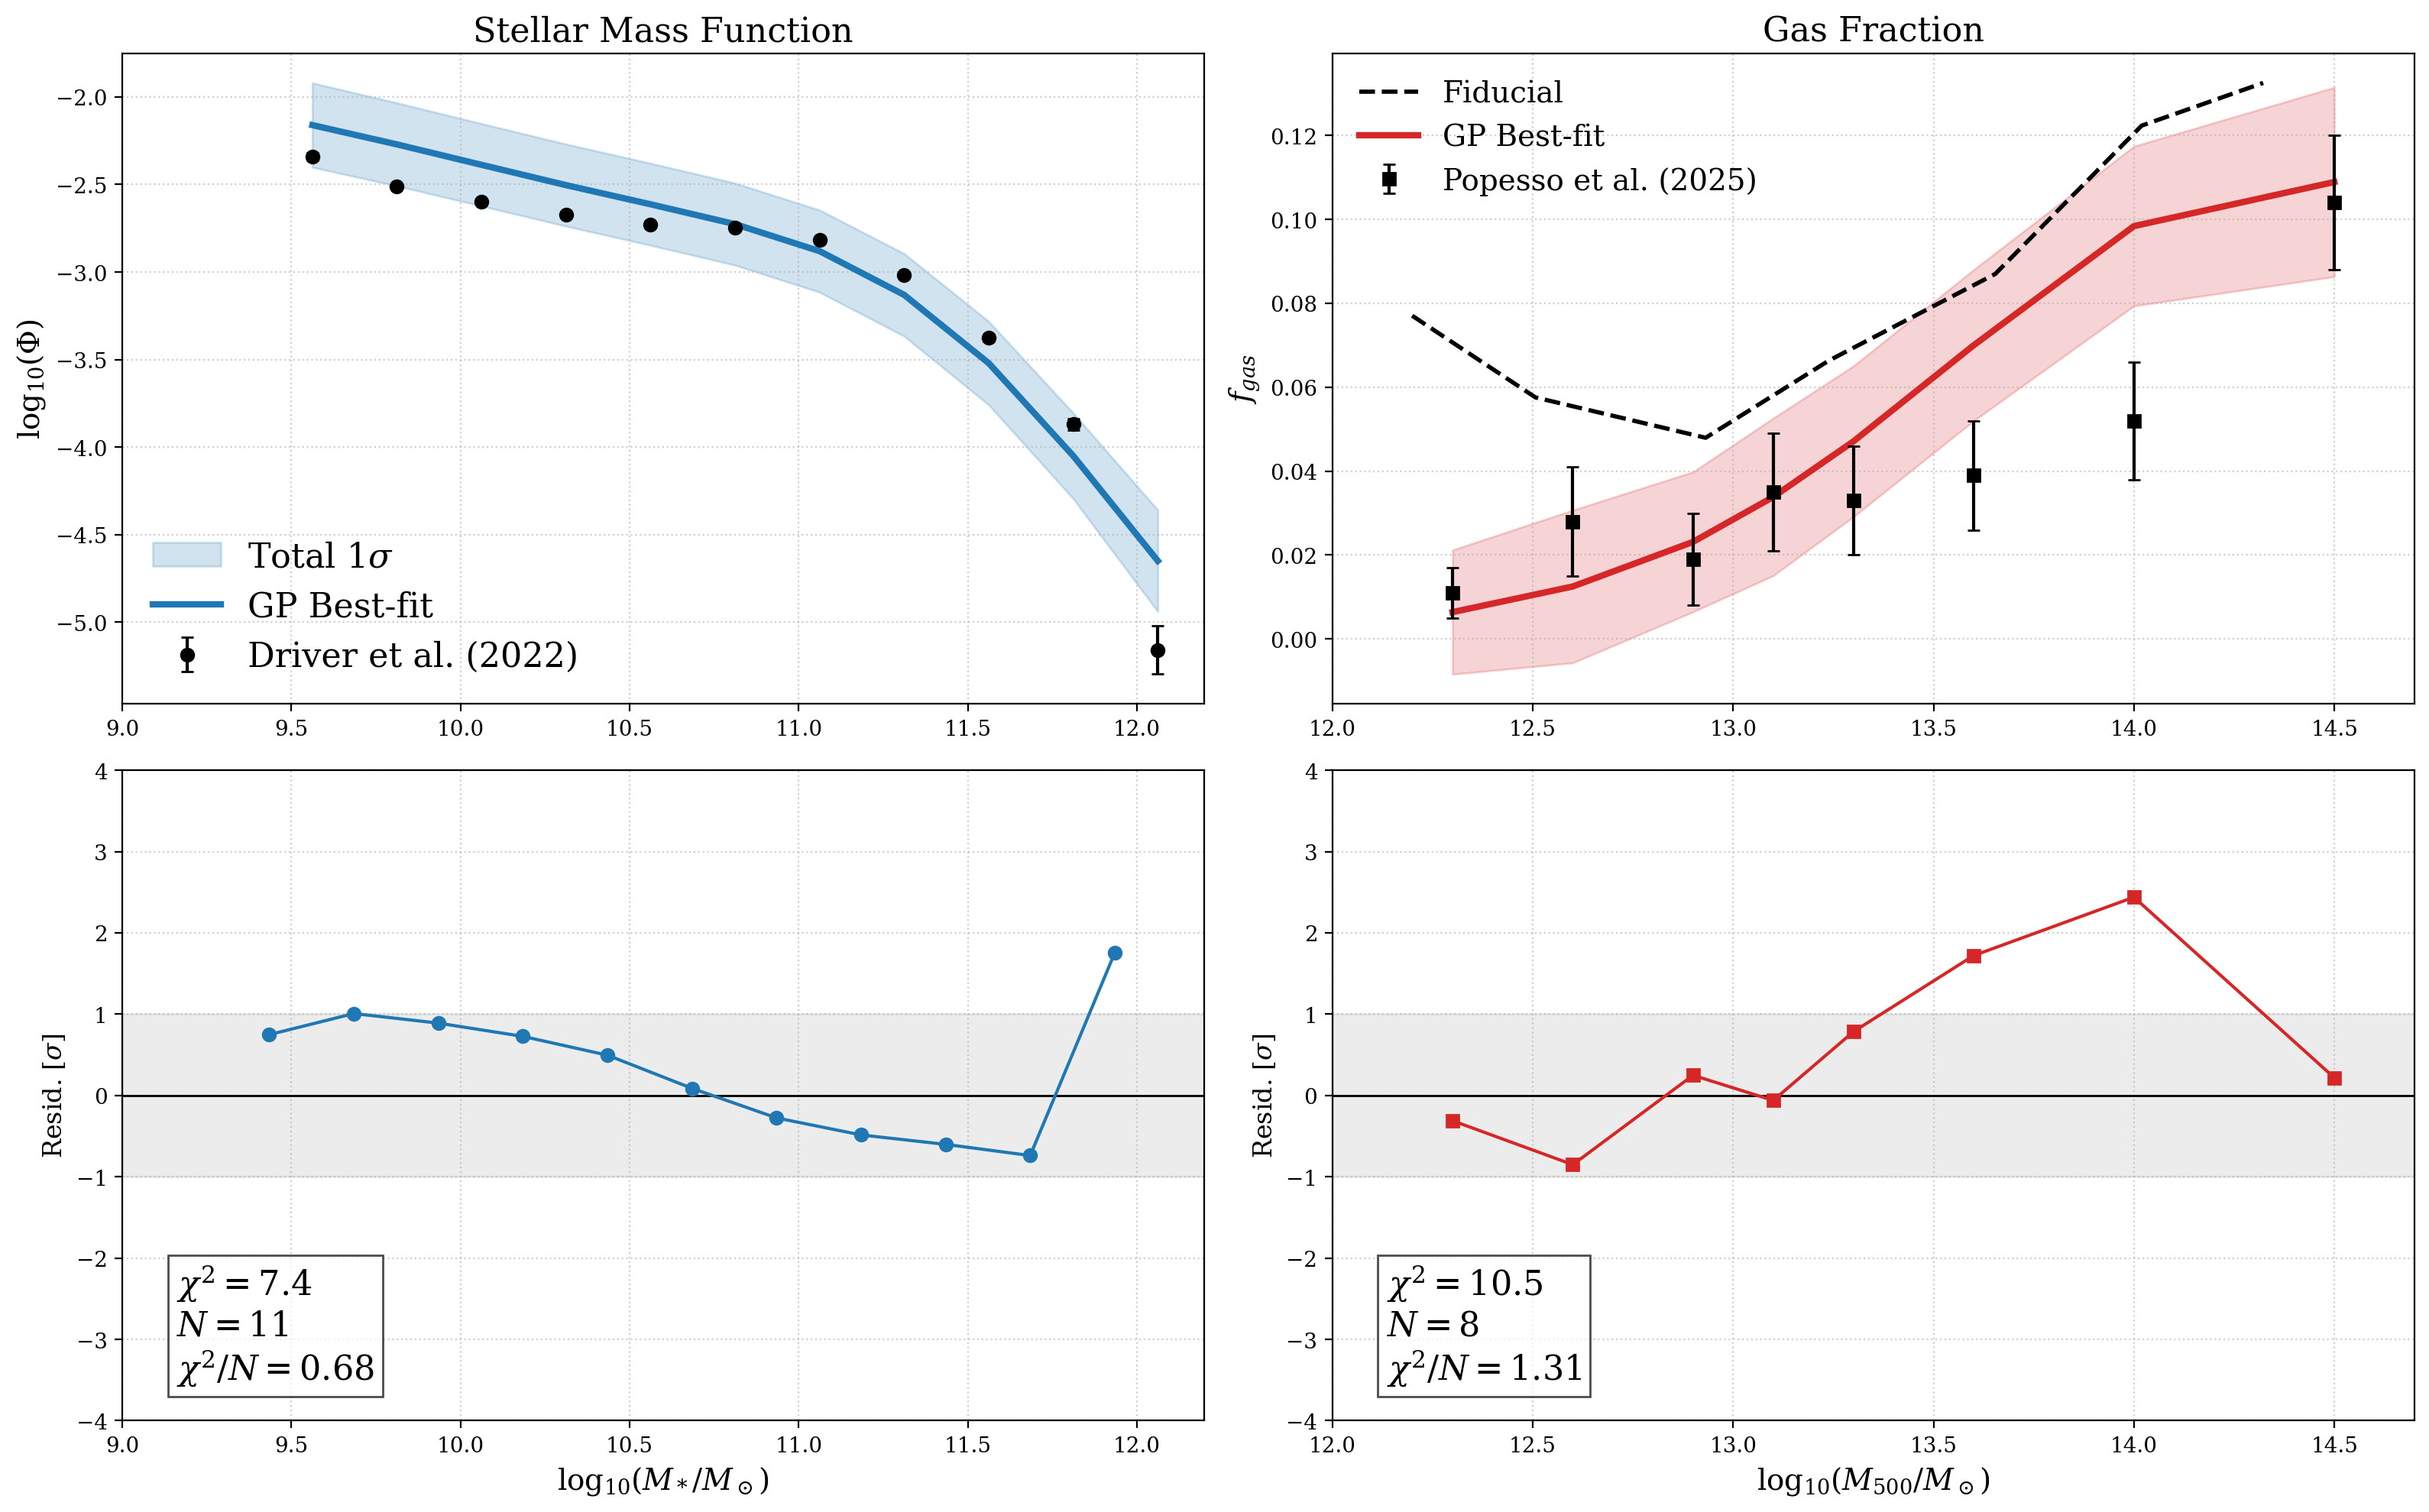

In [136]:
# 1. Best-Fit Calculations
# bf_theta = np.median(flat_samples[:,:7], axis=0)
bf_theta = samples_ext[np.argmax(log_l_ext)]

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
# ax_m1.plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
#                 'k--', lw=2, label='Fiducial')
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

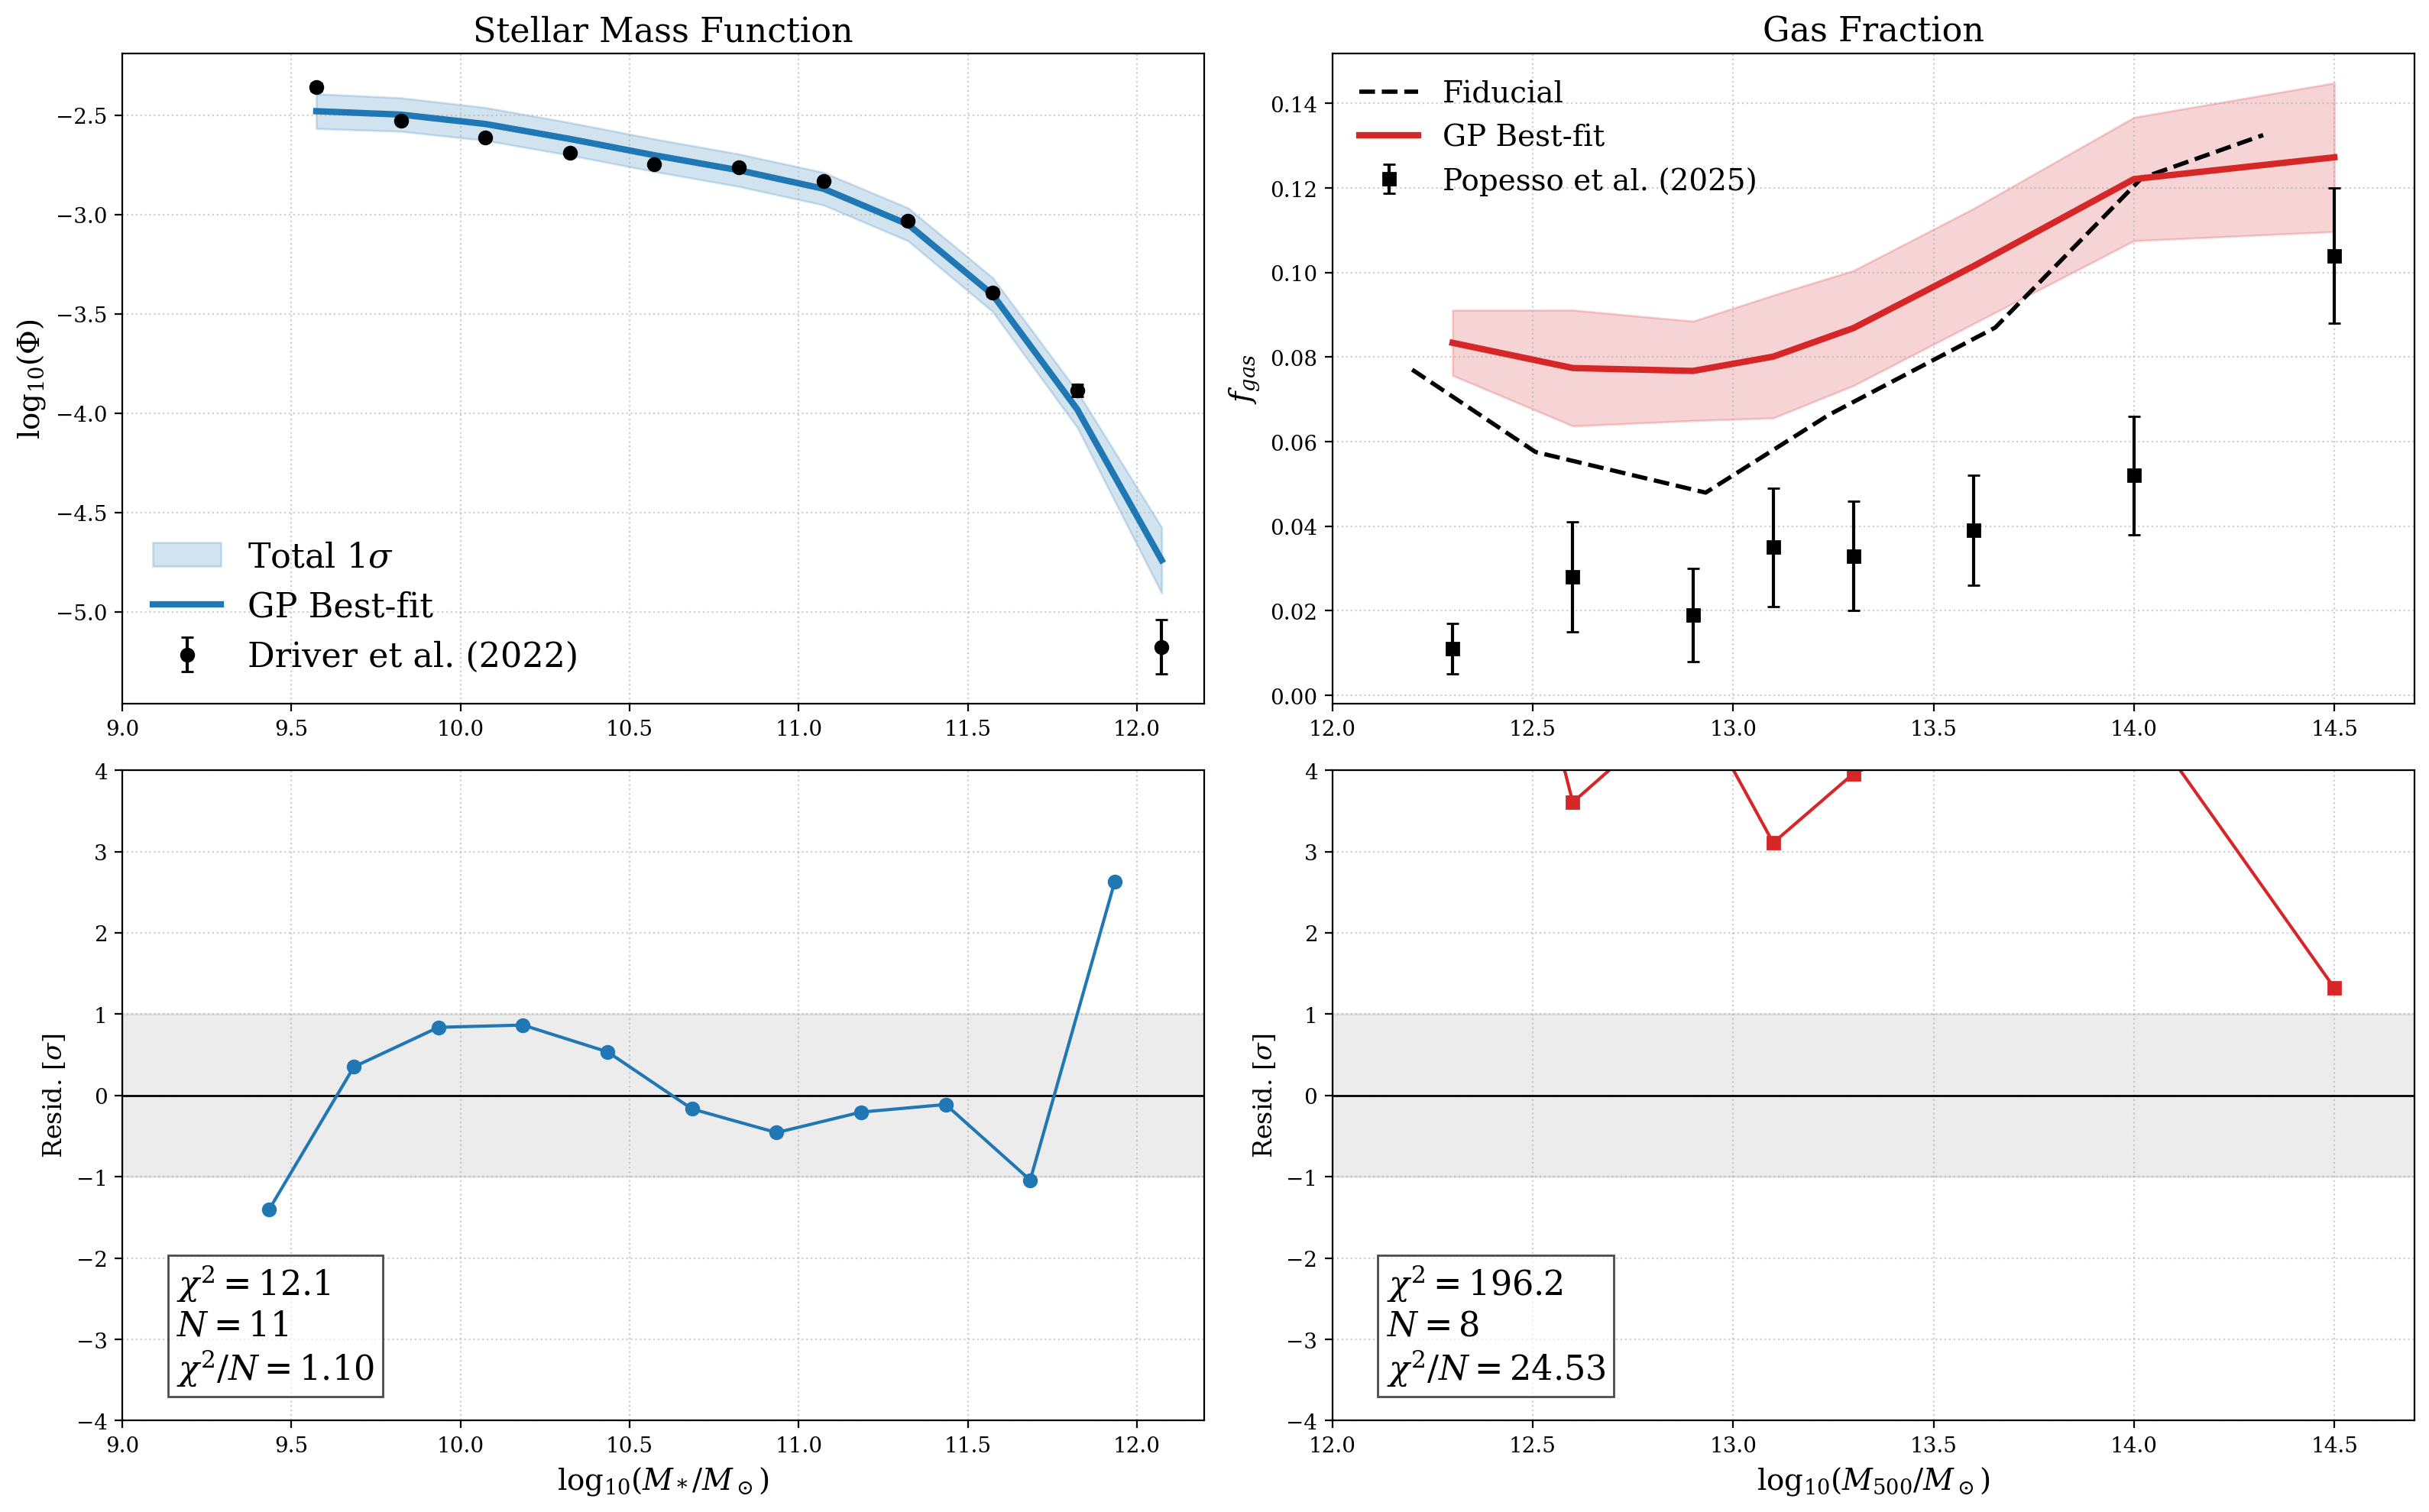

In [109]:
# 1. Best-Fit Calculations
# bf_theta = np.median(flat_samples[:,:7], axis=0)
bf_theta = smf_samples[np.argmax(log_smf)]

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
# ax_m1.plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
#                 'k--', lw=2, label='Fiducial')
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

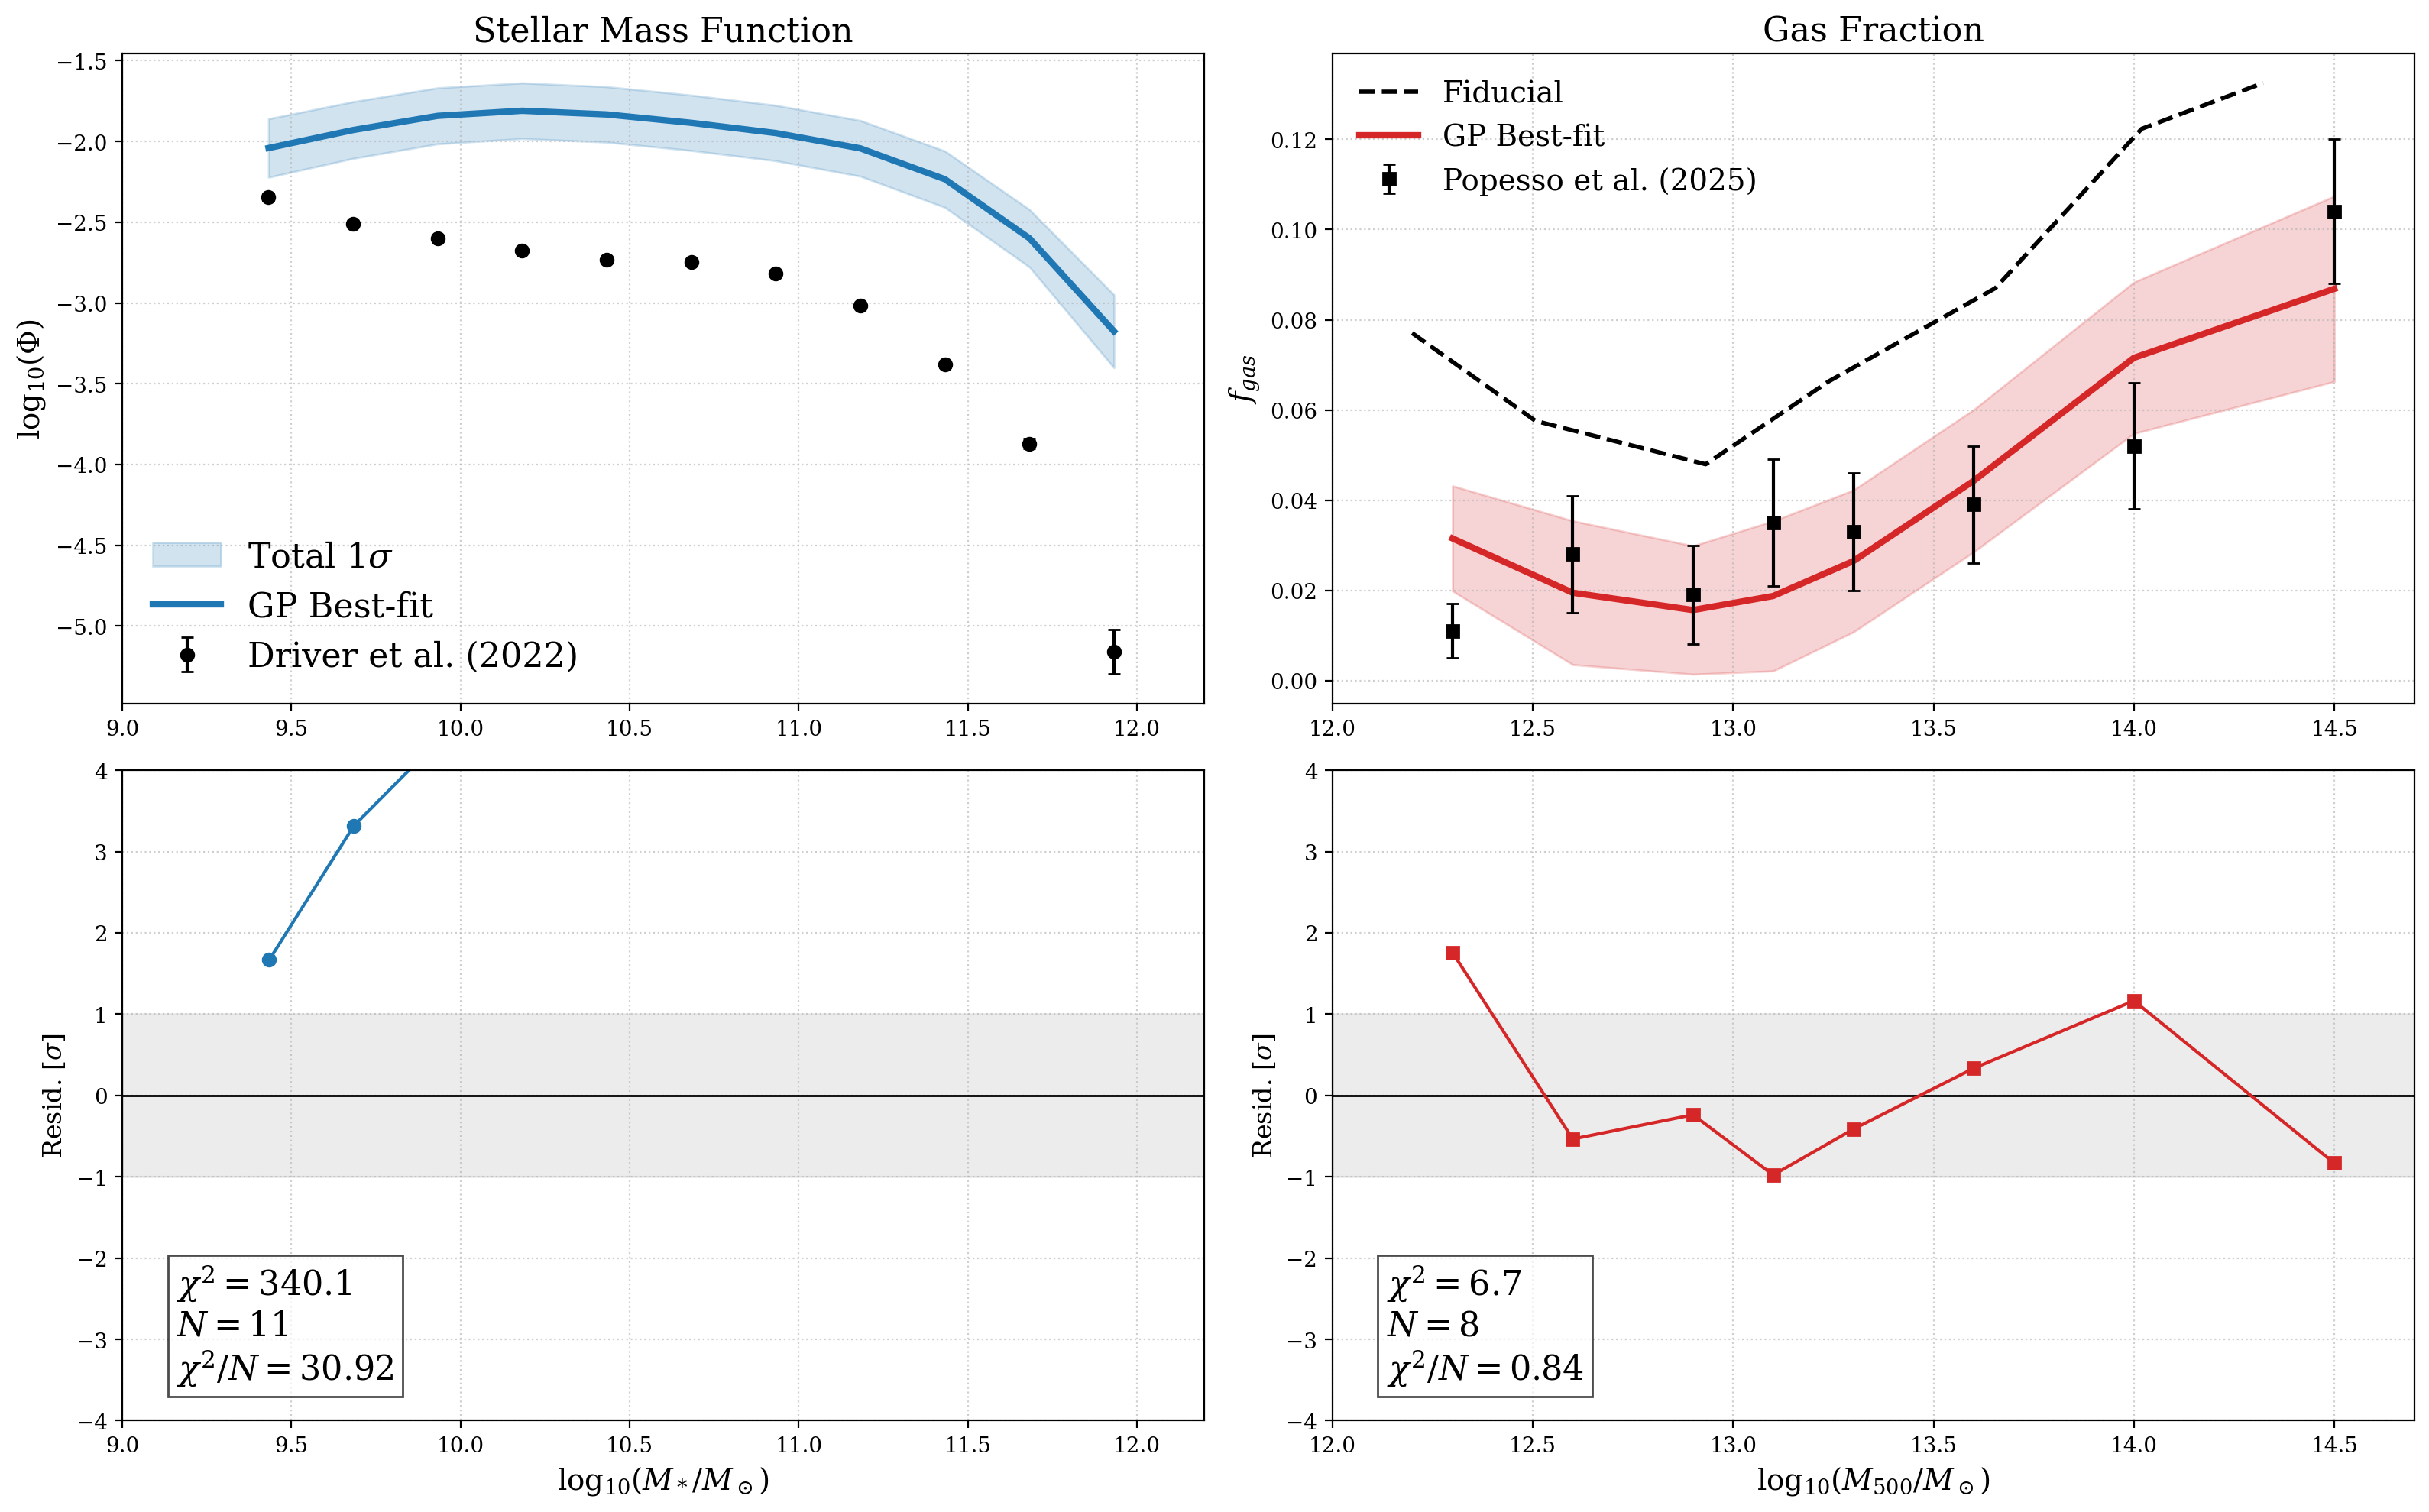

In [110]:
# 1. Best-Fit Calculations
# bf_theta = np.median(flat_samples[:,:7], axis=0)
bf_theta = fgas_samples[np.argmax(log_fgas)]

GAMA_data = model_GAMA(GAMA_corr, bf_theta[7], bf_theta[8])

obs_log_phi = GAMA_data[9:,1]
obs_uncertainty = GAMA_data[9:,2]
mstar = GAMA_data[9:,0]

# SMF Predictions & Chi2
mu_smf, var_smf = get_gp_prediction(bf_theta[:7], mstar, model_smf)
std_tot_smf = np.sqrt(var_smf + obs_uncertainty**2)
resid_smf = (mu_smf - obs_log_phi) / std_tot_smf
chi2_smf = np.sum(resid_smf**2)
n_smf = len(resid_smf)

# Gas Fraction Predictions & Chi2
mu_fgas, var_fgas = get_gp_prediction(bf_theta[:7], data_dict['mhalo'], model_fgas)
std_tot_fgas = np.sqrt(var_fgas + data_dict['fgas_err']**2)
resid_fgas = (mu_fgas - data_dict['fgas_obs']) / std_tot_fgas
chi2_fgas = np.sum(resid_fgas**2)
n_fgas = len(resid_fgas)

# 2. Setup Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

# --- LEFT COLUMN: SMF ---
ax_m1 = axes[0, 0]
ax_m1.set_xlim(9,12.2)
# ax_m1.plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
#                 'k--', lw=2, label='Fiducial')
ax_m1.fill_between(mstar, mu_smf - std_tot_smf, mu_smf + std_tot_smf, 
                        color='C0', alpha=0.2, label='Total $1\sigma$')
ax_m1.plot(mstar, mu_smf, 'C0-', lw=3, label='GP Best-fit')
ax_m1.errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Stats Text Box
stats_smf = f"$\chi^2 = {chi2_smf:.1f}$\n$N = {n_smf}$\n$\chi^2/N = {chi2_smf/n_smf:.2f}$"

ax_m1.set_ylabel(r'$\log_{10}(\Phi)$', fontsize=14)
ax_m1.set_title('Stellar Mass Function', fontsize=16)
ax_m1.legend(loc='lower left', frameon=False, fontsize=16)

# Residuals
ax_r1 = axes[1, 0]
ax_r1.set_xlim(9,12.2)
ax_r1.text(0.05, 0.05, stats_smf, fontsize=16, transform=ax_r1.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r1.axhline(0, color='black', lw=1)
ax_r1.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r1.plot(data_dict['mstar'], resid_smf, 'o-', color='C0')
ax_r1.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r1.set_xlabel(r'$\log_{10}(M_* / M_\odot)$', fontsize=14)
ax_r1.set_ylim(-4, 4)

# --- RIGHT COLUMN: Gas Fraction ---
ax_m2 = axes[0, 1]
ax_m2.set_xlim(12, 14.7)
ax_m2.plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k--', lw=2, label='Fiducial')
ax_m2.fill_between(data_dict['mhalo'], mu_fgas - std_tot_fgas, mu_fgas + std_tot_fgas, 
                        color='C3', alpha=0.2)
ax_m2.plot(data_dict['mhalo'], mu_fgas, 'C3-', lw=3, label='GP Best-fit')
ax_m2.errorbar(data_dict['mhalo'], data_dict['fgas_obs'], yerr=data_dict['fgas_err'], 
                    fmt='ks', capsize=3, label='Popesso et al. (2025)')

# Stats Text Box
stats_fgas = f"$\chi^2 = {chi2_fgas:.1f}$\n$N = {n_fgas}$\n$\chi^2/N = {chi2_fgas/n_fgas:.2f}$"

ax_m2.set_ylabel(r'$f_{gas}$', fontsize=14)
ax_m2.set_title('Gas Fraction', fontsize=16)
ax_m2.legend(loc='upper left', frameon=False, fontsize=14)

# Residuals
ax_r2 = axes[1, 1]
ax_r2.set_xlim(12, 14.7)
ax_r2.text(0.05, 0.05, stats_fgas, fontsize=16, transform=ax_r2.transAxes, bbox=dict(facecolor='white', alpha=0.7), verticalalignment='bottom')
ax_r2.axhline(0, color='black', lw=1)
ax_r2.axhspan(-1, 1, color='gray', alpha=0.15)
ax_r2.plot(data_dict['mhalo'], resid_fgas, 's-', color='C3')
ax_r2.set_ylabel(r'Resid. [$\sigma$]', fontsize=12)
ax_r2.set_xlabel(r'$\log_{10}(M_{500} / M_\odot)$', fontsize=14)
ax_r2.set_ylim(-4, 4)

for ax in axes.flatten(): ax.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [64]:
bf_sigma = np.std(flat_samples[:,:7], axis=0)

dist_bf = np.zeros(31)
for i in range(31):
    diff_sigma = (bf_theta[:7] - np.asarray([wind_en_or[i], wind_vel_or[i], rho_rec_or[i], sf_ts_or[i], ef_kin_or[i], ef_high_or[i], f_re_or[i]])) / bf_sigma
    dist_bf[i] = np.sqrt( np.sum(diff_sigma**2) )

sim_name = 'LH_{:d}'.format(np.argmin(dist_bf))

fid_theta = np.asarray([wind_en_or[30], wind_vel_or[30], rho_rec_or[30], sf_ts_or[30], ef_kin_or[30], ef_high_or[30], f_re_or[30]])


Text(0.5, 0, '$\\log_{10}(M_{500,c} [M_\\odot])$')

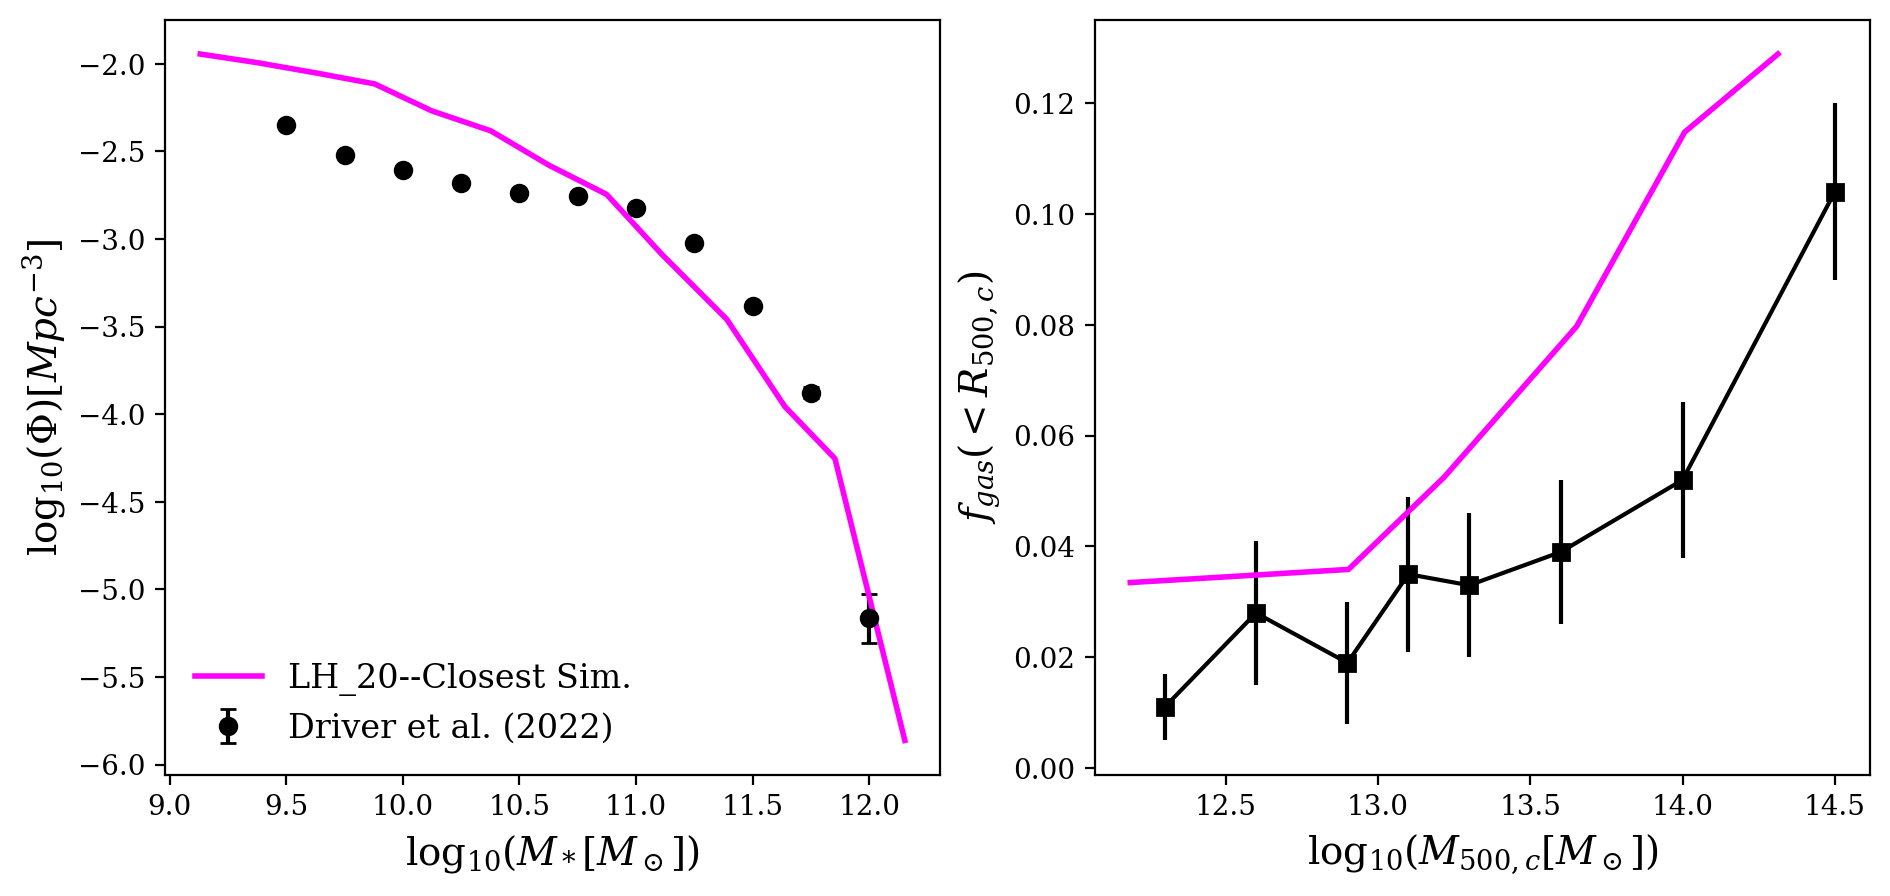

In [65]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(11,5))

#SMF
ax[0].errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')
ax[0].plot(np.log10(zoom_smf[sim_name]['mstar'][0]), np.log10(zoom_smf[sim_name]['smf'][0]),\
    label=sim_name+"--Closest Sim.", color='magenta', linewidth=2)
ax[0].set_ylabel(r'$\log_{10}(\Phi)[Mpc^{-3}]$', fontsize=14)
ax[0].set_xlabel(r'$\log_{10}(M_* [M_\odot])$', fontsize=14)
ax[0].legend(loc='lower left', frameon=False, fontsize=12)

#f_gas
ax[1].errorbar(m500_pp, fgas_pp, yerr=err_pp, marker='s', label='Popesso et al. (2025)', markersize=6, color='k')
ax[1].plot(np.log10(zoom_fgas[sim_name]['m500c'][0]), zoom_fgas[sim_name]['f_gas'][0], label=sim_name+"--Closest Sim.", color='magenta', linewidth=2)

ax[1].set_ylabel(r'$f_{gas}(<R_{500,c})$', fontsize=14)
ax[1].set_xlabel(r'$\log_{10}(M_{500,c} [M_\odot])$', fontsize=14)

Text(0.5, 0.98, 'Cumulative changes to Best-Fit Model')

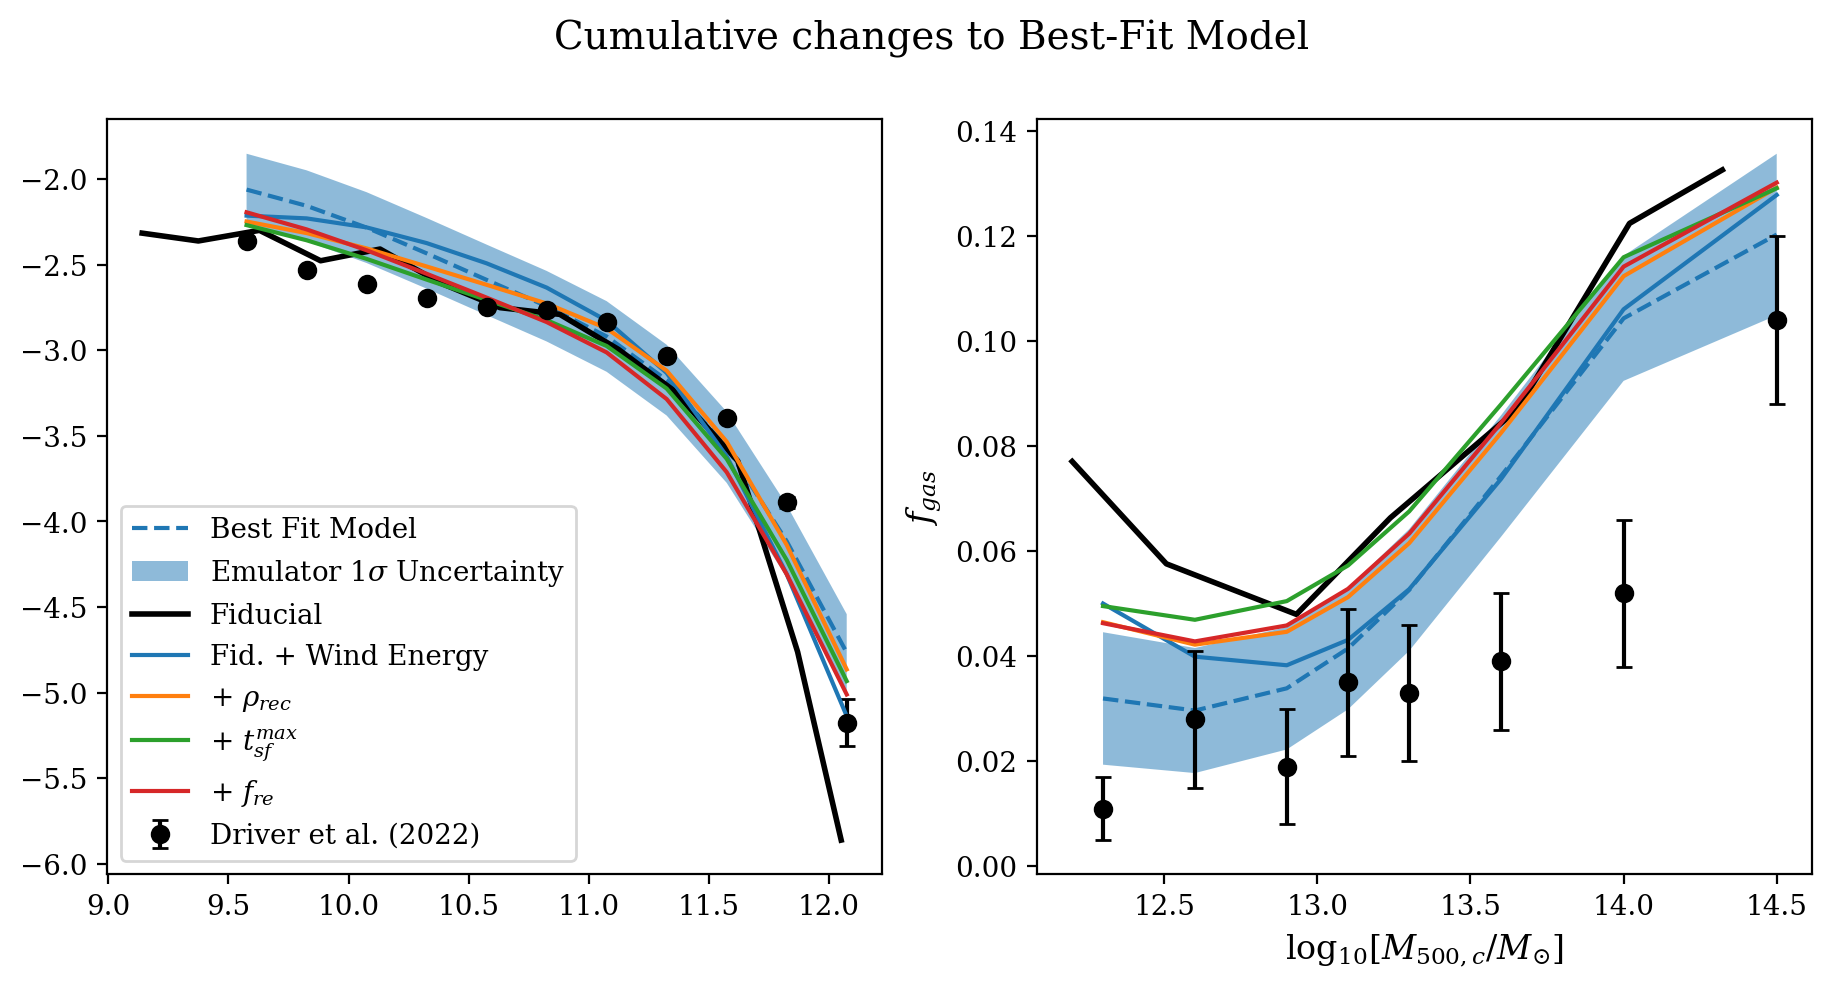

In [52]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(11,5))

# Stellar-Mass Function
ax[0].errorbar(mstar, obs_log_phi, yerr=obs_uncertainty, 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta[:7], mstar, model_smf)
ax[0].plot(mstar, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[0].fill_between(mstar, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[0].plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
                'k', lw=2, label='Fiducial')

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C1', label='+ $\\rho_{rec}$')

# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C2', label='+ $t_{sf}^{max}$')

# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C3', label='+ $f_{re}$')

ax[0].legend(loc='lower left', fontsize=10)

# Gas-Fractions is Clusters
ax[1].errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
)

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta[:7], m500_pp, model_fgas)
ax[1].plot(m500_pp, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[1].fill_between(m500_pp, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[1].plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k', lw=2, label='Fiducial')

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C1', label='+ $\\rho_{rec}$')

# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C2', label='+ $t_{sf}^{max}$')

# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C3', label='+ $f_{re}$')

ax[1].set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
ax[1].set_ylabel('$f_{gas}$', fontsize=12)

plt.suptitle("Cumulative changes to Best-Fit Model", fontsize=14)


RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 8 but got size 10 for tensor number 1 in the list.

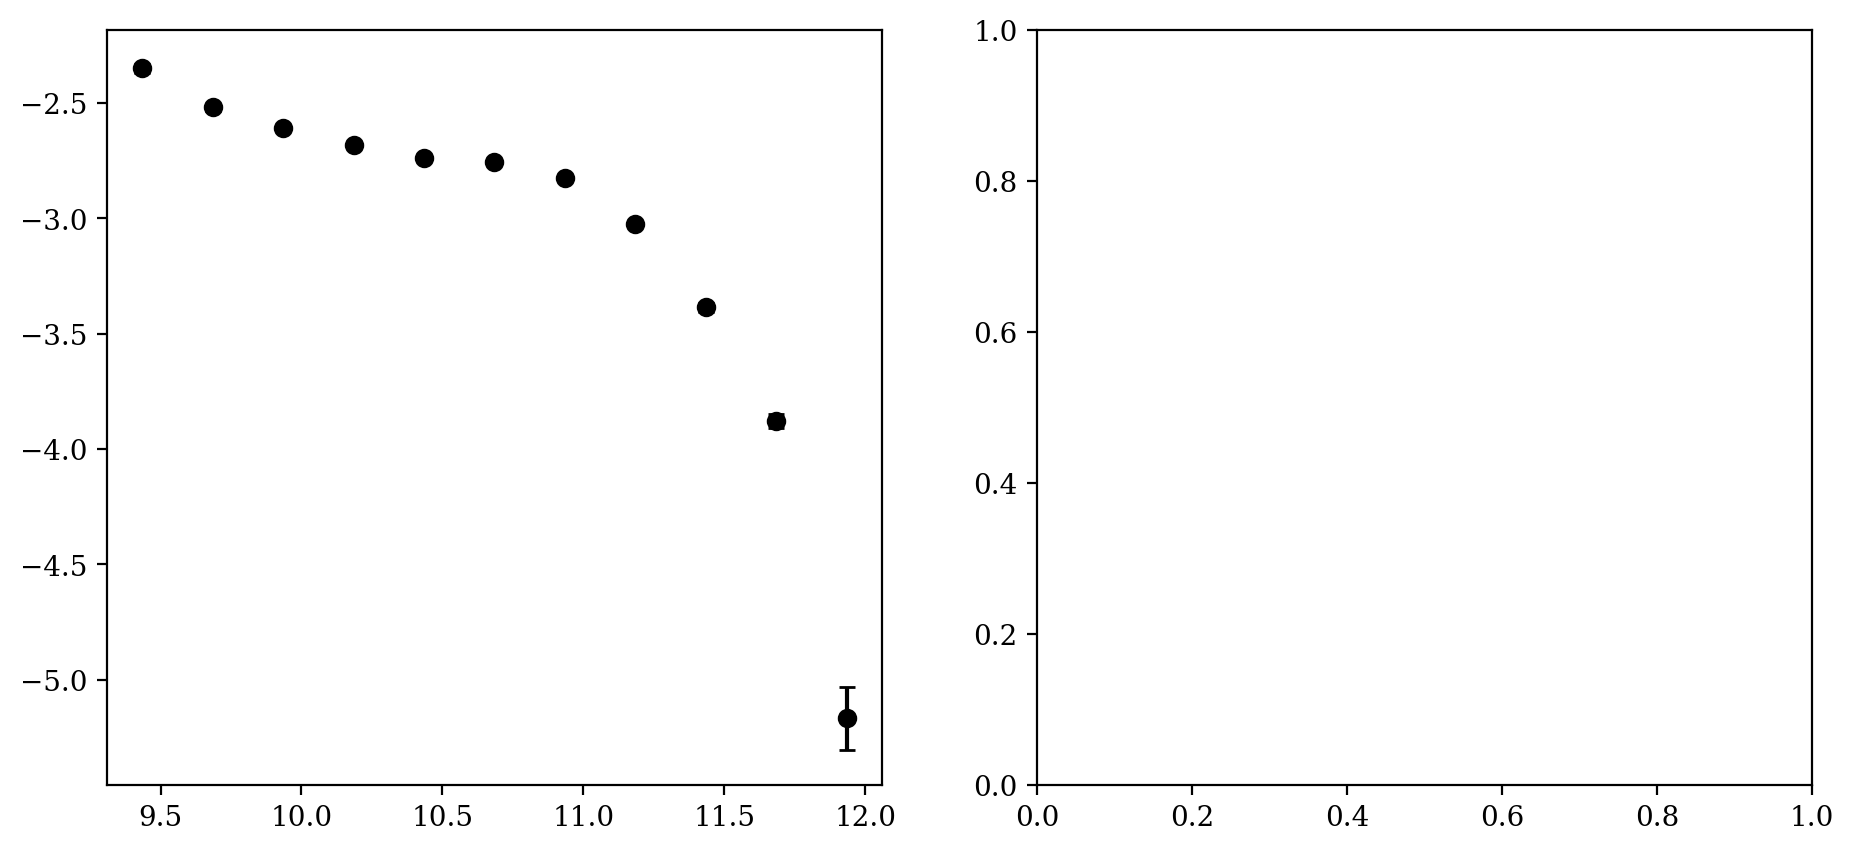

In [53]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(11,5))

# Stellar-Mass Function
ax[0].errorbar(data_dict['mstar'], data_dict['smf_obs'], yerr=data_dict['smf_err'], 
                    fmt='ko', capsize=3, label='Driver et al. (2022)')

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta, mstar, model_smf)
ax[0].plot(mstar, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[0].fill_between(mstar, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[0].plot(fiducial_dict['smf_mstar'], fiducial_dict['smf_phi'], 
                'k', lw=2, label='Fiducial')
ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

ch_theta = np.copy(fid_theta)
# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C1', label='Fid + $\\rho_{rec}$')

ch_theta = np.copy(fid_theta)
# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C2', label='Fid + $t_{sf}^{max}$')

ch_theta = np.copy(fid_theta)
# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, mstar, model_smf)
ax[0].plot(mstar, ch_mu_pred, color='C3', label='Fid + $f_{re}$')

ax[0].legend(loc='lower left', fontsize=10)

# Gas-Fractions is Clusters
ax[1].errorbar(
    m500_pp, 
    fgas_pp, 
    yerr=err_pp, # Error bars show the observation uncertainty
    fmt='o', 
    color='k', 
    capsize=3, 
    zorder=3, # Bring to front
    label='Popesso et al (2025)'
)

# Plot Best-Fit Mean Curve
mu_pred, var_emulator = get_gp_prediction(bf_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, mu_pred, ls='--', label='Best Fit Model', color='C0')
ax[1].fill_between(m500_pp, mu_pred - np.sqrt(var_emulator), mu_pred + np.sqrt(var_emulator), 
    color='C0', alpha=0.5, zorder=2, label='Emulator $1\sigma$ Uncertainty', ec=None)

ax[1].plot(fiducial_dict['fgas_mhalo'], fiducial_dict['fgas_val'], 
                'k', lw=2, label='Fiducial')

ch_theta = np.copy(fid_theta)
# Wind Energy
ch_theta[0] = bf_theta[0]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C0', label='Fid. + Wind Energy')

ch_theta = np.copy(fid_theta)
# Reincorporation Density
ch_theta[2] = bf_theta[2]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C1', label='Fid + $\\rho_{rec}$')

ch_theta = np.copy(fid_theta)
# Timescale of Star-Formation
ch_theta[3] = bf_theta[3]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C2', label='Fid + $t_{sf}^{max}$')

ch_theta = np.copy(fid_theta)
# Reorientation Factor
ch_theta[6] = bf_theta[6]
ch_mu_pred, ch_var_emulator = get_gp_prediction(ch_theta, m500_pp, model_fgas)
ax[1].plot(m500_pp, ch_mu_pred, color='C3', label='+ $f_{re}$')

ax[1].set_xlabel('$\\log_{10}[M_{500,c}/M_{\odot}]$', fontsize=12)
ax[1].set_ylabel('$f_{gas}$', fontsize=12)

plt.suptitle("One parameter shifts to Best-Fit Model", fontsize=14)
